# Guía Completa: Manipulación de Series de Tiempo con Pandas

## Objetivos de Aprendizaje

En este notebook aprenderás a trabajar con datos temporales usando pandas, una de las funcionalidades más poderosas de esta librería:

### Lo que aprenderás:

- **Creación y conversión** de fechas y timestamps
- **Indexación temporal** y operaciones con índices de tiempo
- **Resampling** para cambiar frecuencias temporales
- **Rolling windows** para análisis móviles
- **Agrupaciones temporales** por períodos específicos
- **Manejo de zonas horarias** y localización
- **Visualización** de series de tiempo
- **Tratamiento de datos faltantes** en contexto temporal
- **Casos prácticos** con datos reales

Las series de tiempo son omnipresentes en análisis de datos: ventas, precios, métricas web, sensores IoT, finanzas, etc. Dominar estas técnicas es esencial para cualquier analista de datos.

## 1. Importar Librerías y Configuración

Comenzaremos importando las librerías necesarias para trabajar con series de tiempo.

In [1]:
# Librerías fundamentales
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para trabajar con fechas
from dateutil.relativedelta import relativedelta
import calendar

# Configuración de pandas
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Configuración de visualización
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Configurar formato de fechas en español (opcional)
import locale
try:
    locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')  # Linux/Mac
except:
    try:
        locale.setlocale(locale.LC_TIME, 'Spanish_Spain.1252')  # Windows
    except:
        pass  # Usar configuración por defecto

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Fecha actual: {pd.Timestamp.now()}")

Librerías importadas correctamente!
Pandas version: 2.2.3
NumPy version: 1.26.4
Fecha actual: 2025-10-16 19:15:39.030441


## 2. Creación y Conversión de Fechas

Aprenderemos las diferentes formas de crear y convertir fechas en pandas.

In [6]:
print("CREACIÓN Y CONVERSIÓN DE FECHAS")
print("=" * 35)

# 1. Crear timestamps individuales
print("1. Timestamps individuales:")
fecha1 = pd.Timestamp('2024-01-15')
fecha2 = pd.Timestamp('2024-01-15 14:30:00')
fecha3 = pd.Timestamp(2024, 1, 15, 14, 30, 0)  # año, mes, día, hora, minuto, segundo

print(f"Fecha simple: {fecha1}")
print(f"Fecha con hora: {fecha2}")
print(f"Fecha construida: {fecha3}")
print(f"Timestamp actual: {pd.Timestamp.now()}")


CREACIÓN Y CONVERSIÓN DE FECHAS
1. Timestamps individuales:
Fecha simple: 2024-01-15 00:00:00
Fecha con hora: 2024-01-15 14:30:00
Fecha construida: 2024-01-15 14:30:00
Timestamp actual: 2025-10-16 19:20:21.250782


In [7]:

# 2. Conversión de strings a fechas
print(f"\n2. Conversión de strings:")
fechas_string = ['2024-01-01', '2024-02-15', '2024-03-30']
fechas_convertidas = pd.to_datetime(fechas_string, format='%Y-%m-%d')
print(f"Strings originales: {fechas_string}")
print(f"Fechas convertidas: {fechas_convertidas}")



2. Conversión de strings:
Strings originales: ['2024-01-01', '2024-02-15', '2024-03-30']
Fechas convertidas: DatetimeIndex(['2024-01-01', '2024-02-15', '2024-03-30'], dtype='datetime64[ns]', freq=None)


In [8]:

# 3. Diferentes formatos de fecha
print(f"\n3. Diferentes formatos:")
formatos_diversos = ['01/15/2024', '15-01-2024', 'January 15, 2024']
fechas_formatos = pd.to_datetime(formatos_diversos, format="mixed")
print(f"Formatos diversos: {formatos_diversos}")
print(f"Fechas parseadas: {fechas_formatos}")



3. Diferentes formatos:
Formatos diversos: ['01/15/2024', '15-01-2024', 'January 15, 2024']
Fechas parseadas: DatetimeIndex(['2024-01-15', '2024-01-15', '2024-01-15'], dtype='datetime64[ns]', freq=None)


In [9]:

# 4. Formato específico
print(f"\n4. Formato específico:")
fechas_custom = ['20240115', '20240216', '20240330']
fechas_custom_conv = pd.to_datetime(fechas_custom, format='%Y%m%d')
print(f"Formato YYYYMMDD: {fechas_custom}")
print(f"Convertidas: {fechas_custom_conv}")



4. Formato específico:
Formato YYYYMMDD: ['20240115', '20240216', '20240330']
Convertidas: DatetimeIndex(['2024-01-15', '2024-02-16', '2024-03-30'], dtype='datetime64[ns]', freq=None)


In [10]:

# 5. Rangos de fechas
print(f"\n5. Rangos de fechas:")
rango_diario = pd.date_range(start='2024-01-01', end='2024-01-10', freq='D')
rango_semanal = pd.date_range(start='2024-01-01', periods=10, freq='W')
rango_mensual = pd.date_range(start='2024-01-01', periods=12, freq='M')

print(f"Rango diario (10 días): {rango_diario}")
print(f"Rango semanal (10 semanas): {rango_semanal}")
print(f"Rango mensual (12 meses): {rango_mensual}")



5. Rangos de fechas:
Rango diario (10 días): DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10'], dtype='datetime64[ns]', freq='D')
Rango semanal (10 semanas): DatetimeIndex(['2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28', '2024-02-04', '2024-02-11', '2024-02-18', '2024-02-25', '2024-03-03', '2024-03-10'], dtype='datetime64[ns]', freq='W-SUN')
Rango mensual (12 meses): DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30', '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31', '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31'], dtype='datetime64[ns]', freq='ME')


In [11]:

# 6. Frecuencias comunes
print(f"\n6. Frecuencias disponibles:")
frecuencias = {
    'D': 'Diaria',
    'W': 'Semanal', 
    'M': 'Fin de mes',
    'MS': 'Inicio de mes',
    'Q': 'Trimestral',
    'A': 'Anual',
    'H': 'Horaria',
    'T': 'Minutal',
    'S': 'Segundos'
}

for freq, descripcion in frecuencias.items():
    ejemplo = pd.date_range('2024-01-01', periods=3, freq=freq)
    print(f"  {freq} ({descripcion}): {ejemplo[0]} -> {ejemplo[1]} -> {ejemplo[2]}")


6. Frecuencias disponibles:
  D (Diaria): 2024-01-01 00:00:00 -> 2024-01-02 00:00:00 -> 2024-01-03 00:00:00
  W (Semanal): 2024-01-07 00:00:00 -> 2024-01-14 00:00:00 -> 2024-01-21 00:00:00
  M (Fin de mes): 2024-01-31 00:00:00 -> 2024-02-29 00:00:00 -> 2024-03-31 00:00:00
  MS (Inicio de mes): 2024-01-01 00:00:00 -> 2024-02-01 00:00:00 -> 2024-03-01 00:00:00
  Q (Trimestral): 2024-03-31 00:00:00 -> 2024-06-30 00:00:00 -> 2024-09-30 00:00:00
  A (Anual): 2024-12-31 00:00:00 -> 2025-12-31 00:00:00 -> 2026-12-31 00:00:00
  H (Horaria): 2024-01-01 00:00:00 -> 2024-01-01 01:00:00 -> 2024-01-01 02:00:00
  T (Minutal): 2024-01-01 00:00:00 -> 2024-01-01 00:01:00 -> 2024-01-01 00:02:00
  S (Segundos): 2024-01-01 00:00:00 -> 2024-01-01 00:00:01 -> 2024-01-01 00:00:02


## 3. Crear Series de Tiempo con Datos de Ejemplo

Crearemos datasets de ejemplo que representen casos reales de series de tiempo.

In [12]:
# Crear diferentes tipos de series de tiempo

# 1. Datos de ventas diarias (e-commerce)
print("CREANDO SERIES DE TIEMPO DE EJEMPLO")
print("=" * 40)

fecha_inicio = '2023-01-01'
fecha_fin = '2024-12-31'
fechas_diarias = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Simular ventas con tendencia, estacionalidad y ruido
n_dias = len(fechas_diarias)
tendencia = np.linspace(1000, 1500, n_dias)  # Crecimiento anual
estacionalidad_anual = 200 * np.sin(2 * np.pi * np.arange(n_dias) / 365.25)  # Ciclo anual
estacionalidad_semanal = 100 * np.sin(2 * np.pi * np.arange(n_dias) / 7)  # Ciclo semanal
ruido = np.random.normal(0, 50, n_dias)

ventas = tendencia + estacionalidad_anual + estacionalidad_semanal + ruido
ventas = np.maximum(ventas, 100)  # Asegurar valores positivos

# DataFrame de ventas
df_ventas = pd.DataFrame({
    'fecha': fechas_diarias,
    'ventas': ventas,
    'categoria': np.random.choice(['Electrónicos', 'Ropa', 'Hogar'], n_dias),
    'canal': np.random.choice(['Online', 'Tienda'], n_dias, p=[0.6, 0.4])
})

print(f"1. Datos de ventas diarias:")
print(f"   Período: {df_ventas['fecha'].min()} a {df_ventas['fecha'].max()}")
print(f"   Total registros: {len(df_ventas):,}")
print(f"   Ventas promedio: ${df_ventas['ventas'].mean():.2f}")


CREANDO SERIES DE TIEMPO DE EJEMPLO
1. Datos de ventas diarias:
   Período: 2023-01-01 00:00:00 a 2024-12-31 00:00:00
   Total registros: 731
   Ventas promedio: $1249.55


In [13]:

# 2. Datos de precios de acciones (cada hora de trading)
fechas_horarias = pd.date_range(start='2024-01-01 09:00', 
                               end='2024-03-31 17:00', 
                               freq='H')
# Filtrar solo horas de trading (9-17, lunes a viernes)
fechas_trading = fechas_horarias[(fechas_horarias.hour >= 9) & 
                               (fechas_horarias.hour <= 17) &
                               (fechas_horarias.weekday < 5)]

# Simular precio de acción con random walk
precio_inicial = 100
n_horas = len(fechas_trading)
cambios = np.random.normal(0, 0.5, n_horas)  # Cambios aleatorios
precios = [precio_inicial]

for cambio in cambios[1:]:
    nuevo_precio = precios[-1] * (1 + cambio/100)
    precios.append(nuevo_precio)

df_acciones = pd.DataFrame({
    'timestamp': fechas_trading,
    'precio': precios,
    'volumen': np.random.randint(1000, 10000, len(fechas_trading)),
    'simbolo': 'TECH'
})

print(f"\n2. Datos de precios de acciones (horarios):")
print(f"   Período: {df_acciones['timestamp'].min()} a {df_acciones['timestamp'].max()}")
print(f"   Total registros: {len(df_acciones):,}")
print(f"   Precio promedio: ${df_acciones['precio'].mean():.2f}")



2. Datos de precios de acciones (horarios):
   Período: 2024-01-01 09:00:00 a 2024-03-29 17:00:00
   Total registros: 585
   Precio promedio: $102.82


In [14]:

# 3. Datos de sensores IoT (cada minuto)
fechas_minutos = pd.date_range(start='2024-10-01 00:00', 
                              end='2024-10-07 23:59', 
                              freq='T')

# Simular temperatura con ciclo diario
horas_del_dia = fechas_minutos.hour + fechas_minutos.minute/60
temperatura_base = 20 + 10 * np.sin(2 * np.pi * (horas_del_dia - 6) / 24)
temperatura = temperatura_base + np.random.normal(0, 1, len(fechas_minutos))

df_sensores = pd.DataFrame({
    'timestamp': fechas_minutos,
    'temperatura': temperatura,
    'humedad': 50 + 20 * np.sin(2 * np.pi * horas_del_dia / 24) + np.random.normal(0, 3, len(fechas_minutos)),
    'sensor_id': np.random.choice(['SENSOR_01', 'SENSOR_02', 'SENSOR_03'], len(fechas_minutos))
})

print(f"\n3. Datos de sensores IoT (minutales):")
print(f"   Período: {df_sensores['timestamp'].min()} a {df_sensores['timestamp'].max()}")
print(f"   Total registros: {len(df_sensores):,}")
print(f"   Temperatura promedio: {df_sensores['temperatura'].mean():.1f}°C")

# Mostrar ejemplos de cada dataset
print(f"\nEJEMPLOS DE DATOS:")
print(f"\nVentas (primeras 5 filas):")
print(df_ventas.head())
print(f"\nAcciones (primeras 5 filas):")
print(df_acciones.head())
print(f"\nSensores (primeras 5 filas):")
print(df_sensores.head())


3. Datos de sensores IoT (minutales):
   Período: 2024-10-01 00:00:00 a 2024-10-07 23:59:00
   Total registros: 10,080
   Temperatura promedio: 20.0°C

EJEMPLOS DE DATOS:

Ventas (primeras 5 filas):
       fecha       ventas     categoria   canal
0 2023-01-01  1024.835708          Ropa  Online
1 2023-01-02  1075.395180          Ropa  Online
2 2023-01-03  1138.126693  Electrónicos  Online
3 2023-01-04  1131.911535  Electrónicos  Tienda
4 2023-01-05   961.394765  Electrónicos  Tienda

Acciones (primeras 5 filas):
            timestamp      precio  volumen simbolo
0 2024-01-01 09:00:00  100.000000     2422    TECH
1 2024-01-01 10:00:00  100.420310     4180    TECH
2 2024-01-01 11:00:00  100.694826     5316    TECH
3 2024-01-01 12:00:00  100.574530     7696    TECH
4 2024-01-01 13:00:00  100.390064     1614    TECH

Sensores (primeras 5 filas):
            timestamp  temperatura    humedad  sensor_id
0 2024-10-01 00:00:00     9.960693  52.103767  SENSOR_01
1 2024-10-01 00:01:00     9.8655

## 4. Indexación Temporal

Aprenderemos a configurar y usar índices de tiempo para operaciones eficientes con series temporales.

In [15]:
print("INDEXACIÓN TEMPORAL")
print("=" * 20)

# 1. Configurar índice temporal
# Crear copias con índice temporal
ventas_indexed = df_ventas.set_index('fecha').copy()
acciones_indexed = df_acciones.set_index('timestamp').copy()
sensores_indexed = df_sensores.set_index('timestamp').copy()

print("1. Configuración de índices temporales:")
print(f"   Ventas - Índice: {type(ventas_indexed.index)}")
print(f"   Acciones - Índice: {type(acciones_indexed.index)}")
print(f"   Sensores - Índice: {type(sensores_indexed.index)}")


INDEXACIÓN TEMPORAL
1. Configuración de índices temporales:
   Ventas - Índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   Acciones - Índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
   Sensores - Índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [16]:

# 2. Selección por fechas exactas
print(f"\n2. Selección por fechas exactas:")
fecha_especifica = '2024-01-15'
ventas_dia = ventas_indexed.loc[fecha_especifica]
print(f"   Ventas del {fecha_especifica}:")
print(f"   {ventas_dia}")



2. Selección por fechas exactas:
   Ventas del 2024-01-15:
   ventas       1344.224054
categoria          Hogar
canal             Tienda
Name: 2024-01-15 00:00:00, dtype: object


In [17]:

# 3. Selección por rangos de fechas
print(f"\n3. Selección por rangos:")
ventas_enero = ventas_indexed.loc['2024-01-01':'2024-01-31']
print(f"   Ventas de enero 2024: {len(ventas_enero)} registros")
print(f"   Promedio diario: ${ventas_enero['ventas'].mean():.2f}")



3. Selección por rangos:
   Ventas de enero 2024: 31 registros
   Promedio diario: $1324.41


In [18]:

# 4. Selección por año y mes
print(f"\n4. Selección por períodos:")
ventas_2024 = ventas_indexed.loc['2024']
ventas_feb_2024 = ventas_indexed.loc['2024-02']
print(f"   Ventas de 2024: {len(ventas_2024)} registros")
print(f"   Ventas de febrero 2024: {len(ventas_feb_2024)} registros")



4. Selección por períodos:
   Ventas de 2024: 366 registros
   Ventas de febrero 2024: 29 registros


In [19]:

# 5. Selección parcial con strings
print(f"\n5. Selección parcial con strings:")
acciones_marzo = acciones_indexed.loc['2024-03']
print(f"   Precios de marzo 2024: {len(acciones_marzo)} registros")
print(f"   Precio promedio: ${acciones_marzo['precio'].mean():.2f}")



5. Selección parcial con strings:
   Precios de marzo 2024: 189 registros
   Precio promedio: $100.92


In [20]:

# 6. Operaciones con datetime accessors
print(f"\n6. Extracción de componentes de fecha:")
ventas_con_componentes = ventas_indexed.copy()
ventas_con_componentes['año'] = ventas_con_componentes.index.year
ventas_con_componentes['mes'] = ventas_con_componentes.index.month
ventas_con_componentes['día_semana'] = ventas_con_componentes.index.dayofweek
ventas_con_componentes['nombre_mes'] = ventas_con_componentes.index.month_name()
ventas_con_componentes['es_fin_semana'] = ventas_con_componentes.index.dayofweek >= 5

print("   Componentes extraídos (primeras 5 filas):")
componentes_muestra = ventas_con_componentes[['ventas', 'año', 'mes', 'día_semana', 'nombre_mes', 'es_fin_semana']].head()
print(componentes_muestra)



6. Extracción de componentes de fecha:
   Componentes extraídos (primeras 5 filas):
                 ventas   año  mes  día_semana nombre_mes  es_fin_semana
fecha                                                                   
2023-01-01  1024.835708  2023    1           6    January           True
2023-01-02  1075.395180  2023    1           0    January          False
2023-01-03  1138.126693  2023    1           1    January          False
2023-01-04  1131.911535  2023    1           2    January          False
2023-01-05   961.394765  2023    1           3    January          False


In [21]:

# 7. Filtros usando componentes de fecha
print(f"\n7. Filtros usando componentes:")
ventas_fines_semana = ventas_con_componentes[ventas_con_componentes['es_fin_semana']]
ventas_lunes = ventas_con_componentes[ventas_con_componentes.index.dayofweek == 0]

print(f"   Ventas en fines de semana: {len(ventas_fines_semana)} registros")
print(f"   Promedio fin de semana: ${ventas_fines_semana['ventas'].mean():.2f}")
print(f"   Ventas los lunes: {len(ventas_lunes)} registros")
print(f"   Promedio lunes: ${ventas_lunes['ventas'].mean():.2f}")



7. Filtros usando componentes:
   Ventas en fines de semana: 209 registros
   Promedio fin de semana: $1211.08
   Ventas los lunes: 105 registros
   Promedio lunes: $1331.28


In [22]:

# 8. Selección de últimos períodos
print(f"\n8. Selección de períodos recientes:")
ultimos_30_dias = ventas_indexed.tail(30)
ultimos_7_dias = ventas_indexed.last('7D')
ultima_semana = ventas_indexed.last('W')

print(f"   Últimos 30 registros: {len(ultimos_30_dias)} días")
print(f"   Últimos 7 días: {len(ultimos_7_dias)} registros")
print(f"   Última semana completa: {len(ultima_semana)} registros")


8. Selección de períodos recientes:
   Últimos 30 registros: 30 días
   Últimos 7 días: 7 registros
   Última semana completa: 2 registros


## 5. Resampling - Cambio de Frecuencias Temporales

El resampling permite cambiar la frecuencia de los datos temporales, agregando o interpolando según sea necesario.

In [24]:
print("RESAMPLING - CAMBIO DE FRECUENCIAS")
print("=" * 40)

# 1. Downsampling - De mayor a menor frecuencia (agregación)
print("1. DOWNSAMPLING (Agregación):")

# De diario a semanal
ventas_semanales = ventas_indexed['ventas'].resample('W').sum()
print(f"   Ventas diarias → semanales:")
print(f"   Original: {len(ventas_indexed)} registros diarios")
print(f"   Agregado: {len(ventas_semanales)} registros semanales")
print(f"   Promedio semanal: ${ventas_semanales.mean():.2f}")

# De diario a mensual con diferentes agregaciones
ventas_mensuales = ventas_indexed['ventas'].resample('M').agg({
    'suma': 'sum',
    'promedio': 'mean',
    'mediana': 'median',
    'max': 'max',
    'min': 'min',
    'conteo': 'count'
})

print(f"\n   Ventas mensuales (múltiples estadísticos):")
print(ventas_mensuales.head())

# De horario a diario para acciones
acciones_diarias = acciones_indexed.resample('D').agg({
    'precio': ['mean', 'max', 'min', 'last'],  # Múltiples estadísticos para precio
    'volumen': 'sum'                           # Volumen total del día
})

# Aplanar columnas multi-nivel
acciones_diarias.columns = ['precio_promedio', 'precio_max', 'precio_min', 'precio_close', 'volumen_total']

print(f"\n   Acciones horarias → diarias:")
print(f"   Original: {len(acciones_indexed)} registros horarios")
print(f"   Agregado: {len(acciones_diarias)} registros diarios")
print(acciones_diarias.head())


RESAMPLING - CAMBIO DE FRECUENCIAS
1. DOWNSAMPLING (Agregación):
   Ventas diarias → semanales:
   Original: 731 registros diarios
   Agregado: 106 registros semanales
   Promedio semanal: $8617.20

   Ventas mensuales (múltiples estadísticos):
                    suma     promedio      mediana          max          min  conteo
fecha                                                                               
2023-01-31  32745.333094  1056.301068  1073.783681  1186.649034   879.411381      31
2023-02-28  32495.893558  1160.567627  1153.238478  1321.831604   979.759877      28
2023-03-31  38399.006437  1238.677627  1231.757998  1401.332413  1067.505171      31
2023-04-30  37820.378586  1260.679286  1276.897045  1464.984521  1071.665491      30
2023-05-31  38432.154580  1239.746922  1243.046208  1413.584164  1077.804534      31

   Acciones horarias → diarias:
   Original: 585 registros horarios
   Agregado: 89 registros diarios
            precio_promedio  precio_max  precio_min  prec

In [25]:

# 2. Upsampling - De menor a mayor frecuencia (interpolación)
print(f"\n2. UPSAMPLING (Interpolación):")

# De mensual a diario con interpolación
ventas_mensuales_simple = ventas_indexed['ventas'].resample('M').mean()
ventas_diarias_interpoladas = ventas_mensuales_simple.resample('D').interpolate()

print(f"   Ventas mensuales → diarias (interpolación):")
print(f"   Original: {len(ventas_mensuales_simple)} registros mensuales")
print(f"   Interpolado: {len(ventas_diarias_interpoladas)} registros diarios")

# Diferentes métodos de interpolación
ventas_upsampled = ventas_mensuales_simple.resample('D').asfreq()  # Sin llenar
ventas_ffill = ventas_mensuales_simple.resample('D').ffill()      # Forward fill
ventas_bfill = ventas_mensuales_simple.resample('D').bfill()      # Backward fill

print(f"\n   Métodos de upsampling:")
print(f"   Sin llenar (NaN): {ventas_upsampled.isna().sum()} valores faltantes")
print(f"   Forward fill: {ventas_ffill.isna().sum()} valores faltantes")
print(f"   Backward fill: {ventas_bfill.isna().sum()} valores faltantes")



2. UPSAMPLING (Interpolación):
   Ventas mensuales → diarias (interpolación):
   Original: 24 registros mensuales
   Interpolado: 701 registros diarios

   Métodos de upsampling:
   Sin llenar (NaN): 677 valores faltantes
   Forward fill: 0 valores faltantes
   Backward fill: 0 valores faltantes


In [26]:

# 3. Resampling de datos de alta frecuencia (sensores)
print(f"\n3. RESAMPLING DE ALTA FRECUENCIA:")

# De minutal a horario
sensores_horarios = sensores_indexed.resample('H').agg({
    'temperatura': ['mean', 'max', 'min', 'std'],
    'humedad': ['mean', 'max', 'min'],
    'sensor_id': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]  # Moda
})

# Aplanar columnas multinivel
sensores_horarios.columns = [f'{col[0]}_{col[1]}' if col[1] != '<lambda>' else f'{col[0]}_mode' 
                            for col in sensores_horarios.columns]

print(f"   Sensores minutales → horarios:")
print(f"   Original: {len(sensores_indexed)} registros por minuto")
print(f"   Agregado: {len(sensores_horarios)} registros por hora")
print(sensores_horarios.head())



3. RESAMPLING DE ALTA FRECUENCIA:
   Sensores minutales → horarios:
   Original: 10080 registros por minuto
   Agregado: 168 registros por hora
                     temperatura_mean  temperatura_max  temperatura_min  temperatura_std  humedad_mean  humedad_max  humedad_min sensor_id_mode
timestamp                                                                                                                                      
2024-10-01 00:00:00         10.482888        12.154512         7.726739         1.029012     52.586830    59.426628    42.174658      SENSOR_02
2024-10-01 01:00:00         10.537932        13.802862         9.069468         0.793438     57.210554    62.794504    51.650901      SENSOR_01
2024-10-01 02:00:00         12.163867        14.180212         9.568805         1.030323     61.798559    70.070685    54.509467      SENSOR_02
2024-10-01 03:00:00         13.850916        17.599184        10.561189         1.457691     65.468798    71.306381    59.518367      S

In [27]:

# 4. Resampling por grupos
print(f"\n4. RESAMPLING POR GRUPOS:")

# Ventas por categoría y mes
ventas_categoria_mes = (ventas_indexed.groupby('categoria')['ventas']
                       .resample('M').sum()
                       .unstack(level=0, fill_value=0))

print(f"   Ventas mensuales por categoría:")
print(ventas_categoria_mes.head())



4. RESAMPLING POR GRUPOS:
   Ventas mensuales por categoría:
categoria   Electrónicos         Hogar          Ropa
fecha                                               
2023-01-31  12328.018526   5188.004046  15229.310522
2023-02-28   7836.085958  16319.190881   8340.616719
2023-03-31  16109.342946  10976.359074  11313.304418
2023-04-30  14996.993180  12252.923007  10570.462399
2023-05-31   8518.705335  17655.576816  12257.872428


In [29]:

# 5. Resampling con funciones personalizadas
print(f"\n5. FUNCIONES PERSONALIZADAS:")

def rango_ventas(x):
    return x.max() - x.min()

def coeficiente_variacion(x):
    return (x.std() / x.mean()) * 100 if x.mean() != 0 else 0

# Forma correcta: usar diccionario para renombrar
ventas_stats_custom = ventas_indexed['ventas'].resample('M').agg({
    'total': 'sum',
    'promedio': 'mean', 
    'rango': rango_ventas,
    'cv_pct': coeficiente_variacion
})

print(f"   Estadísticos personalizados por mes:")
print(ventas_stats_custom.head())


5. FUNCIONES PERSONALIZADAS:
   Estadísticos personalizados por mes:
                   total     promedio       rango    cv_pct
fecha                                                      
2023-01-31  32745.333094  1056.301068  307.237654  7.985585
2023-02-28  32495.893558  1160.567627  342.071727  6.599131
2023-03-31  38399.006437  1238.677627  333.827242  7.535077
2023-04-30  37820.378586  1260.679286  393.319030  7.323992
2023-05-31  38432.154580  1239.746922  335.779631  7.327575


## 6. Rolling Windows - Análisis Móviles

Las ventanas móviles permiten calcular estadísticos sobre períodos deslizantes, muy útiles para suavizar datos y detectar tendencias.

In [30]:
print("ROLLING WINDOWS - ANÁLISIS MÓVILES")
print("=" * 40)

# 1. Medias móviles básicas
print("1. MEDIAS MÓVILES:")

# Medias móviles de diferentes períodos para ventas
ventas_series = ventas_indexed['ventas']
media_movil_7 = ventas_series.rolling(window=7).mean()
media_movil_30 = ventas_series.rolling(window=30).mean()
media_movil_90 = ventas_series.rolling(window=90).mean()

print(f"   Media móvil 7 días: {media_movil_7.dropna().head()}")
print(f"   Media móvil 30 días: {media_movil_30.dropna().head()}")

# 2. Múltiples estadísticos con rolling
print(f"\n2. MÚLTIPLES ESTADÍSTICOS MÓVILES:")

rolling_stats = ventas_series.rolling(window=30).agg({
    'media': 'mean',
    'mediana': 'median',
    'std': 'std',
    'min': 'min',
    'max': 'max',
    'percentil_25': lambda x: x.quantile(0.25),
    'percentil_75': lambda x: x.quantile(0.75)
})

print(f"   Estadísticos móviles de 30 días:")
print(rolling_stats.dropna().head())

# 3. Rolling con ventana temporal (no por número de registros)
print(f"\n3. VENTANAS TEMPORALES:")

# Ventanas de tiempo fijo (ej: 7 días, independiente del número de registros)
media_movil_7d = ventas_series.rolling('7D').mean()
suma_movil_mes = ventas_series.rolling('30D').sum()

print(f"   Media móvil de 7 días (temporal):")
print(f"   Últimos valores: {media_movil_7d.tail()}")

# 4. Rolling con datos de alta frecuencia (acciones)
print(f"\n4. ANÁLISIS TÉCNICO FINANCIERO:")

precios = acciones_indexed['precio']

# Indicadores técnicos comunes
sma_20 = precios.rolling(window=20).mean()  # Simple Moving Average 20 períodos
ema_20 = precios.ewm(span=20).mean()        # Exponential Moving Average
bollinger_std = precios.rolling(window=20).std()
bollinger_upper = sma_20 + (2 * bollinger_std)  # Banda superior Bollinger
bollinger_lower = sma_20 - (2 * bollinger_std)  # Banda inferior Bollinger

# RSI simplificado
delta = precios.diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

indicadores_tecnicos = pd.DataFrame({
    'precio': precios,
    'sma_20': sma_20,
    'ema_20': ema_20,
    'bollinger_upper': bollinger_upper,
    'bollinger_lower': bollinger_lower,
    'rsi': rsi
})

print(f"   Indicadores técnicos (últimos 5 registros):")
print(indicadores_tecnicos.tail())

# 5. Rolling con funciones personalizadas
print(f"\n5. FUNCIONES PERSONALIZADAS:")

def volatilidad(x):
    """Calcular volatilidad como desviación estándar de retornos"""
    if len(x) < 2:
        return np.nan
    retornos = x.pct_change().dropna()
    return retornos.std() * np.sqrt(252)  # Anualizada

def sharpe_ratio(x, risk_free_rate=0.02):
    """Calcular ratio de Sharpe simplificado"""
    if len(x) < 2:
        return np.nan
    retornos = x.pct_change().dropna()
    excess_return = retornos.mean() * 252 - risk_free_rate  # Anualizado
    volatility = retornos.std() * np.sqrt(252)
    return excess_return / volatility if volatility != 0 else 0

# Aplicar funciones personalizadas
volatilidad_movil = precios.rolling(window=30).apply(volatilidad)
sharpe_movil = precios.rolling(window=60).apply(sharpe_ratio)

metricas_financieras = pd.DataFrame({
    'precio': precios,
    'volatilidad_30d': volatilidad_movil,
    'sharpe_60d': sharpe_movil
})

print(f"   Métricas financieras personalizadas:")
print(metricas_financieras.dropna().tail())

# 6. Expanding windows (ventanas acumulativas)
print(f"\n6. VENTANAS ACUMULATIVAS:")

# Desde el inicio hasta cada punto
media_acumulativa = ventas_series.expanding().mean()
suma_acumulativa = ventas_series.expanding().sum()
max_acumulativo = ventas_series.expanding().max()

print(f"   Estadísticos acumulativos (últimos 5):")
stats_acumulativos = pd.DataFrame({
    'ventas': ventas_series,
    'media_acum': media_acumulativa,
    'suma_acum': suma_acumulativa,
    'max_acum': max_acumulativo
})
print(stats_acumulativos.tail())

# 7. Shift - Desplazamiento temporal
print(f"\n7. DESPLAZAMIENTOS TEMPORALES:")

# Comparar con períodos anteriores
ventas_con_lags = pd.DataFrame({
    'ventas': ventas_series,
    'ventas_1d_antes': ventas_series.shift(1),
    'ventas_7d_antes': ventas_series.shift(7),
    'ventas_30d_antes': ventas_series.shift(30),
    'cambio_diario': ventas_series.diff(),
    'cambio_semanal': ventas_series.diff(7),
    'crecimiento_diario_pct': ventas_series.pct_change()
})

print(f"   Comparaciones temporales (últimos 5):")
print(ventas_con_lags.tail())

ROLLING WINDOWS - ANÁLISIS MÓVILES
1. MEDIAS MÓVILES:
   Media móvil 7 días: fecha
2023-01-07    1038.366211
2023-01-08    1044.417037
2023-01-09    1046.164292
2023-01-10    1049.521334
2023-01-11    1039.434288
Name: ventas, dtype: float64
   Media móvil 30 días: fecha
2023-01-30    1051.956135
2023-01-31    1057.349913
2023-02-01    1063.466955
2023-02-02    1061.611846
2023-02-03    1056.540125
Name: ventas, dtype: float64

2. MÚLTIPLES ESTADÍSTICOS MÓVILES:
   Estadísticos móviles de 30 días:
                  media      mediana        std         min          max  percentil_25  percentil_75
fecha                                                                                               
2023-01-30  1051.956135  1070.487585  82.189847  879.411381  1179.148239    979.980210   1112.681415
2023-01-31  1057.349913  1074.589430  85.587993  879.411381  1186.649034    979.980210   1117.531957
2023-02-01  1063.466955  1075.020908  93.146287  879.411381  1258.906447    979.980210   1126

## 7. Agrupaciones Temporales

Las agrupaciones por períodos temporales permiten análisis sofisticados por días de la semana, meses, trimestres, etc.

In [31]:
print("AGRUPACIONES TEMPORALES")
print("=" * 25)

# 1. Agrupación por componentes de fecha
print("1. AGRUPACIÓN POR COMPONENTES:")

# Ventas por día de la semana
ventas_por_dia_semana = (ventas_indexed.groupby(ventas_indexed.index.dayofweek)['ventas']
                        .agg(['mean', 'sum', 'count']))
ventas_por_dia_semana.index = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

print(f"   Ventas por día de la semana:")
print(ventas_por_dia_semana)

# Ventas por mes del año
ventas_por_mes = (ventas_indexed.groupby(ventas_indexed.index.month)['ventas']
                 .agg(['mean', 'sum']))
ventas_por_mes.index = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                       'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

print(f"\n   Ventas por mes del año:")
print(ventas_por_mes)

# 2. Agrupación por múltiples componentes
print(f"\n2. AGRUPACIONES MÚLTIPLES:")

# Por año y mes
ventas_año_mes = (ventas_indexed.groupby([ventas_indexed.index.year, ventas_indexed.index.month])['ventas']
                 .agg(['mean', 'sum']))
ventas_año_mes.index.names = ['Año', 'Mes']

print(f"   Ventas por año y mes (primeras 10):")
print(ventas_año_mes.head(10))

# Por categoría y día de la semana
ventas_categoria_dia = (ventas_indexed.groupby(['categoria', ventas_indexed.index.dayofweek])['ventas']
                       .mean().unstack(fill_value=0))
ventas_categoria_dia.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

print(f"\n   Ventas promedio por categoría y día de la semana:")
print(ventas_categoria_dia)

# 3. Agrupación por períodos personalizados
print(f"\n3. PERÍODOS PERSONALIZADOS:")

# Crear período personalizado (trimestres)
def trimestre(fecha):
    return f"Q{(fecha.month - 1) // 3 + 1}-{fecha.year}"

ventas_trimestre = (ventas_indexed.groupby(ventas_indexed.index.map(trimestre))['ventas']
                   .agg(['sum', 'mean', 'count']))

print(f"   Ventas por trimestre:")
print(ventas_trimestre)

# Por partes del día
def parte_del_dia(hora):
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noche'
    else:
        return 'Madrugada'

# Aplicar a datos de acciones
acciones_parte_dia = (acciones_indexed.groupby(acciones_indexed.index.hour.map(parte_del_dia))
                     ['precio'].agg(['mean', 'std', 'count']))

print(f"\n   Precios de acciones por parte del día:")
print(acciones_parte_dia)

# 4. Análisis estacional
print(f"\n4. ANÁLISIS ESTACIONAL:")

# Detectar patrones estacionales
ventas_indexed['año'] = ventas_indexed.index.year
ventas_indexed['mes'] = ventas_indexed.index.month
ventas_indexed['día_año'] = ventas_indexed.index.dayofyear

# Promedio por día del año (detectar estacionalidad)
patron_anual = ventas_indexed.groupby('día_año')['ventas'].mean()

# Estadísticos por mes para detectar estacionalidad
estacionalidad_mensual = ventas_indexed.groupby('mes')['ventas'].agg([
    'mean', 'std', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
])
estacionalidad_mensual.columns = ['Media', 'Std', 'Min', 'Max', 'Q25', 'Q75']

print(f"   Análisis estacional por mes:")
print(estacionalidad_mensual)

# 5. Comparaciones año sobre año
print(f"\n5. COMPARACIONES AÑO SOBRE AÑO:")

# Ventas del mismo mes en diferentes años
ventas_pivot_año = ventas_indexed.pivot_table(
    values='ventas', 
    index=ventas_indexed.index.month,
    columns=ventas_indexed.index.year,
    aggfunc='mean'
)
ventas_pivot_año.index = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

print(f"   Ventas promedio por mes y año:")
print(ventas_pivot_año)

# Crecimiento año sobre año
if len(ventas_pivot_año.columns) > 1:
    años = sorted(ventas_pivot_año.columns)
    for i in range(1, len(años)):
        año_actual = años[i]
        año_anterior = años[i-1]
        crecimiento = ((ventas_pivot_año[año_actual] - ventas_pivot_año[año_anterior]) / 
                      ventas_pivot_año[año_anterior] * 100)
        print(f"\n   Crecimiento {año_anterior} → {año_actual} (%):")
        print(crecimiento.round(2))

# 6. Agrupación por eventos especiales
print(f"\n6. EVENTOS ESPECIALES:")

# Definir fechas especiales (ejemplo)
fechas_especiales = {
    'Black Friday': ['2023-11-24', '2024-11-29'],
    'Navidad': ['2023-12-25', '2024-12-25'],
    'Año Nuevo': ['2023-01-01', '2024-01-01']
}

def es_fecha_especial(fecha):
    fecha_str = fecha.strftime('%Y-%m-%d')
    for evento, fechas in fechas_especiales.items():
        if fecha_str in fechas:
            return evento
    return 'Normal'

ventas_indexed['tipo_dia'] = ventas_indexed.index.map(es_fecha_especial)
ventas_por_evento = ventas_indexed.groupby('tipo_dia')['ventas'].agg(['mean', 'sum', 'count'])

print(f"   Ventas por tipo de día:")
print(ventas_por_evento)

AGRUPACIONES TEMPORALES
1. AGRUPACIÓN POR COMPONENTES:
   Ventas por día de la semana:
                  mean            sum  count
Lunes      1331.278281  139784.219489    105
Martes     1340.446530  140746.885687    105
Miércoles  1292.759699  134447.008724    104
Jueves     1200.683320  124871.065323    104
Viernes    1158.251503  120458.156260    104
Sábado     1170.986002  121782.544233    104
Domingo    1250.789739  131332.922579    105

   Ventas por mes del año:
            mean           sum
Ene  1190.356752  73802.118607
Feb  1295.667516  73853.048400
Mar  1355.722367  84054.786767
Abr  1388.501006  83310.060337
May  1359.977842  84318.626192
Jun  1289.475425  77368.525499
Jul  1219.073147  75582.535100
Ago  1142.186043  70815.534671
Sep  1112.177786  66730.667167
Oct  1134.749293  70354.456144
Nov  1204.089602  72245.376131
Dic  1306.243021  80987.067279

2. AGRUPACIONES MÚLTIPLES:
   Ventas por año y mes (primeras 10):
                 mean           sum
Año  Mes           

## 8. Visualización de Series de Tiempo

Las visualizaciones especializadas para datos temporales ayudan a identificar patrones, tendencias y anomalías.

VISUALIZACIONES DE SERIES DE TIEMPO


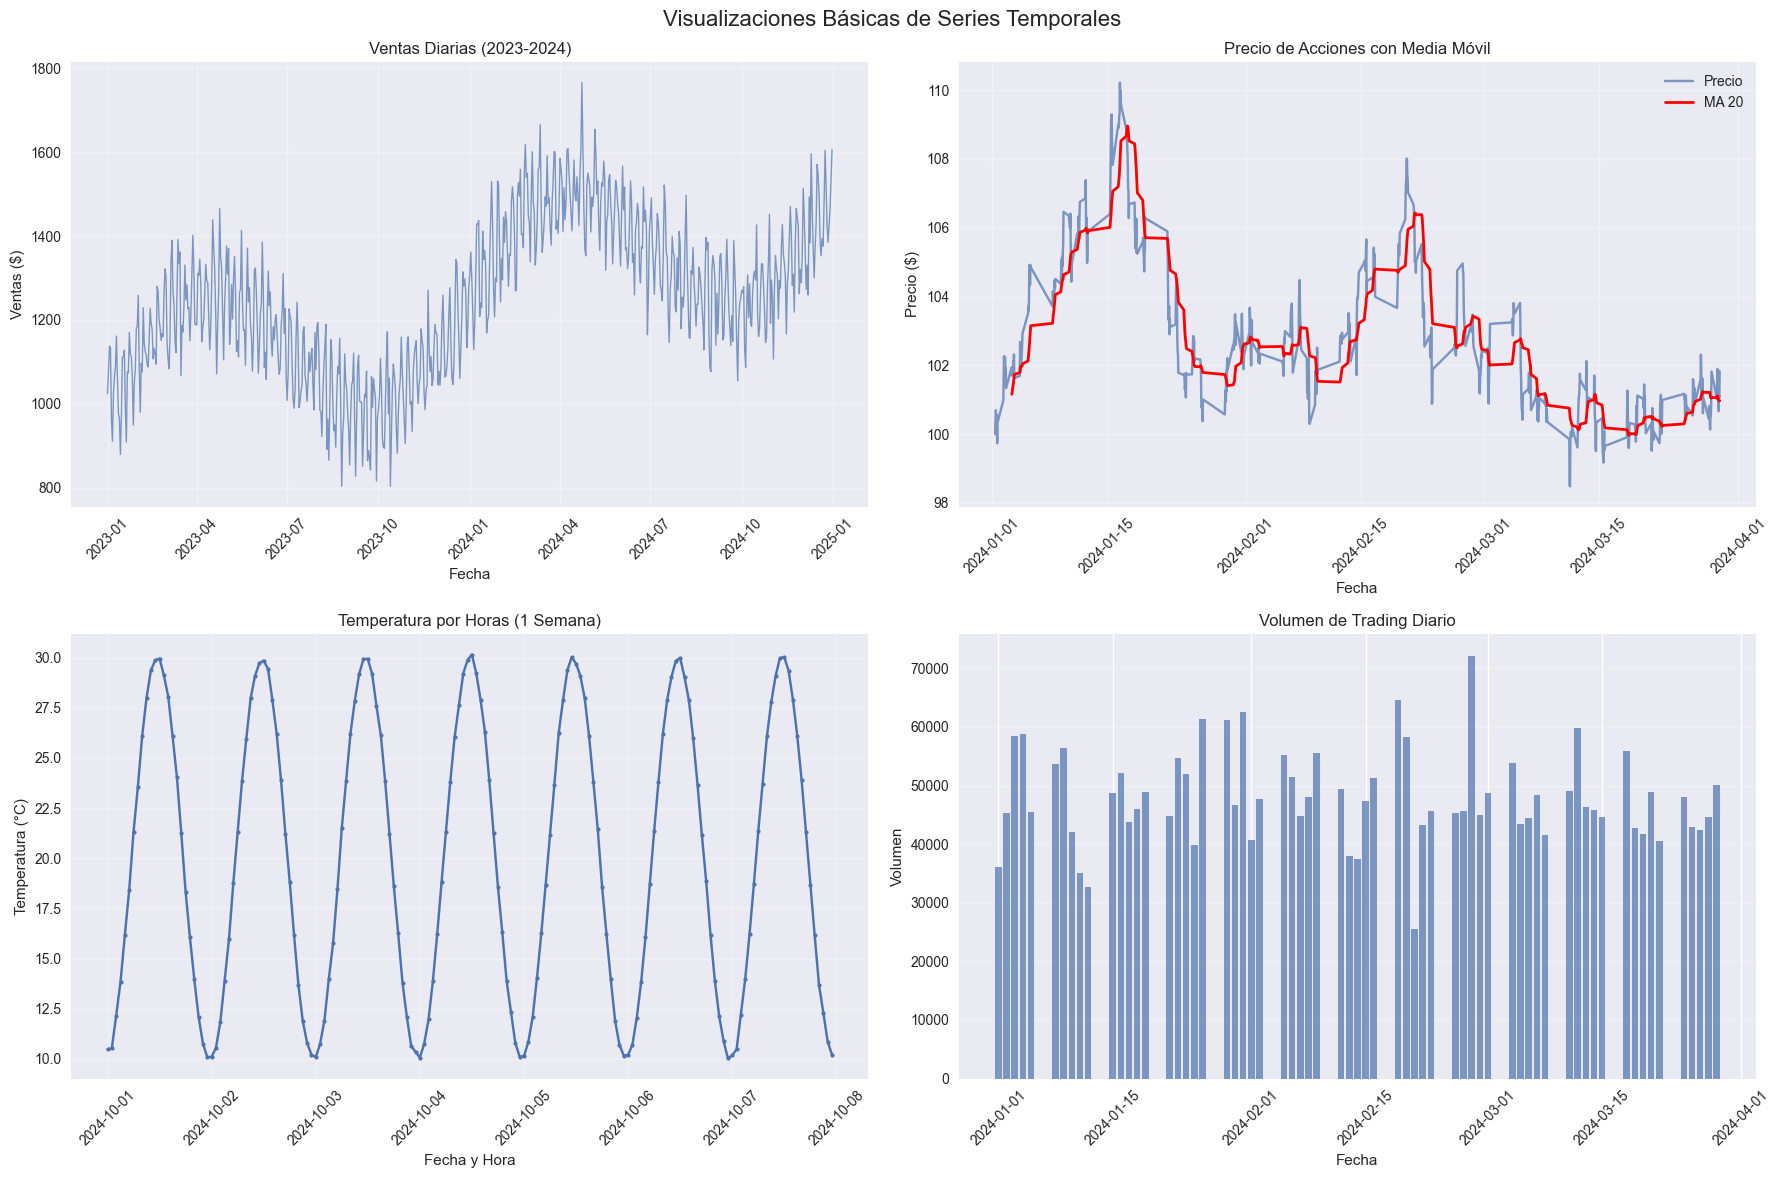

In [33]:
# Visualizaciones especializadas para series de tiempo

# 1. Gráfico básico de serie temporal
print("VISUALIZACIONES DE SERIES DE TIEMPO")
print("=" * 40)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Visualizaciones Básicas de Series Temporales', fontsize=16)

# Ventas diarias
axes[0, 0].plot(ventas_indexed.index, ventas_indexed['ventas'], alpha=0.7, linewidth=1)
axes[0, 0].set_title('Ventas Diarias (2023-2024)')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Ventas ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Precios de acciones con media móvil
axes[0, 1].plot(acciones_indexed.index, acciones_indexed['precio'], alpha=0.7, label='Precio')
sma_20 = acciones_indexed['precio'].rolling(window=20).mean()
axes[0, 1].plot(acciones_indexed.index, sma_20, color='red', linewidth=2, label='MA 20')
axes[0, 1].set_title('Precio de Acciones con Media Móvil')
axes[0, 1].set_xlabel('Fecha')
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Temperatura por días (muestra de una semana)
temp_semana = sensores_indexed['temperatura'].resample('H').mean().head(24*7)
axes[1, 0].plot(temp_semana.index, temp_semana.values, marker='o', markersize=3)
axes[1, 0].set_title('Temperatura por Horas (1 Semana)')
axes[1, 0].set_xlabel('Fecha y Hora')
axes[1, 0].set_ylabel('Temperatura (°C)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Volumen de acciones como gráfico de barras
volumen_diario = acciones_indexed['volumen'].resample('D').sum()
axes[1, 1].bar(volumen_diario.index, volumen_diario.values, alpha=0.7, width=0.8)
axes[1, 1].set_title('Volumen de Trading Diario')
axes[1, 1].set_xlabel('Fecha')
axes[1, 1].set_ylabel('Volumen')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


2. MÚLTIPLES SERIES:


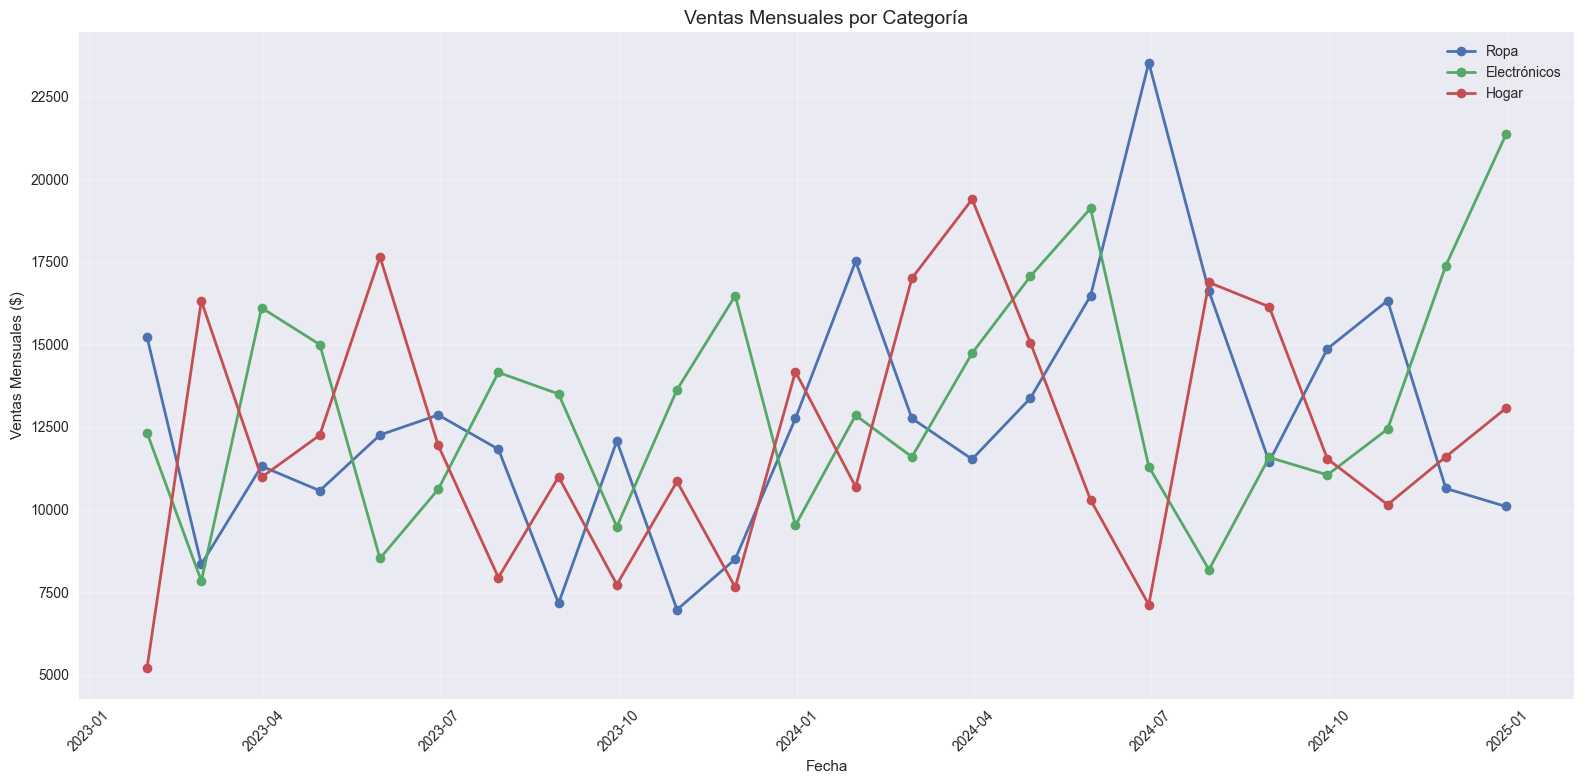

In [34]:

# 2. Gráfico de múltiples series
print("2. MÚLTIPLES SERIES:")

fig, ax = plt.subplots(figsize=(16, 8))

# Comparar ventas por categoría
for categoria in ventas_indexed['categoria'].unique():
    datos_categoria = ventas_indexed[ventas_indexed['categoria'] == categoria]
    ventas_mensuales_cat = datos_categoria['ventas'].resample('M').sum()
    ax.plot(ventas_mensuales_cat.index, ventas_mensuales_cat.values, 
           marker='o', linewidth=2, label=categoria)

ax.set_title('Ventas Mensuales por Categoría', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas Mensuales ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3. BANDAS DE CONFIANZA:


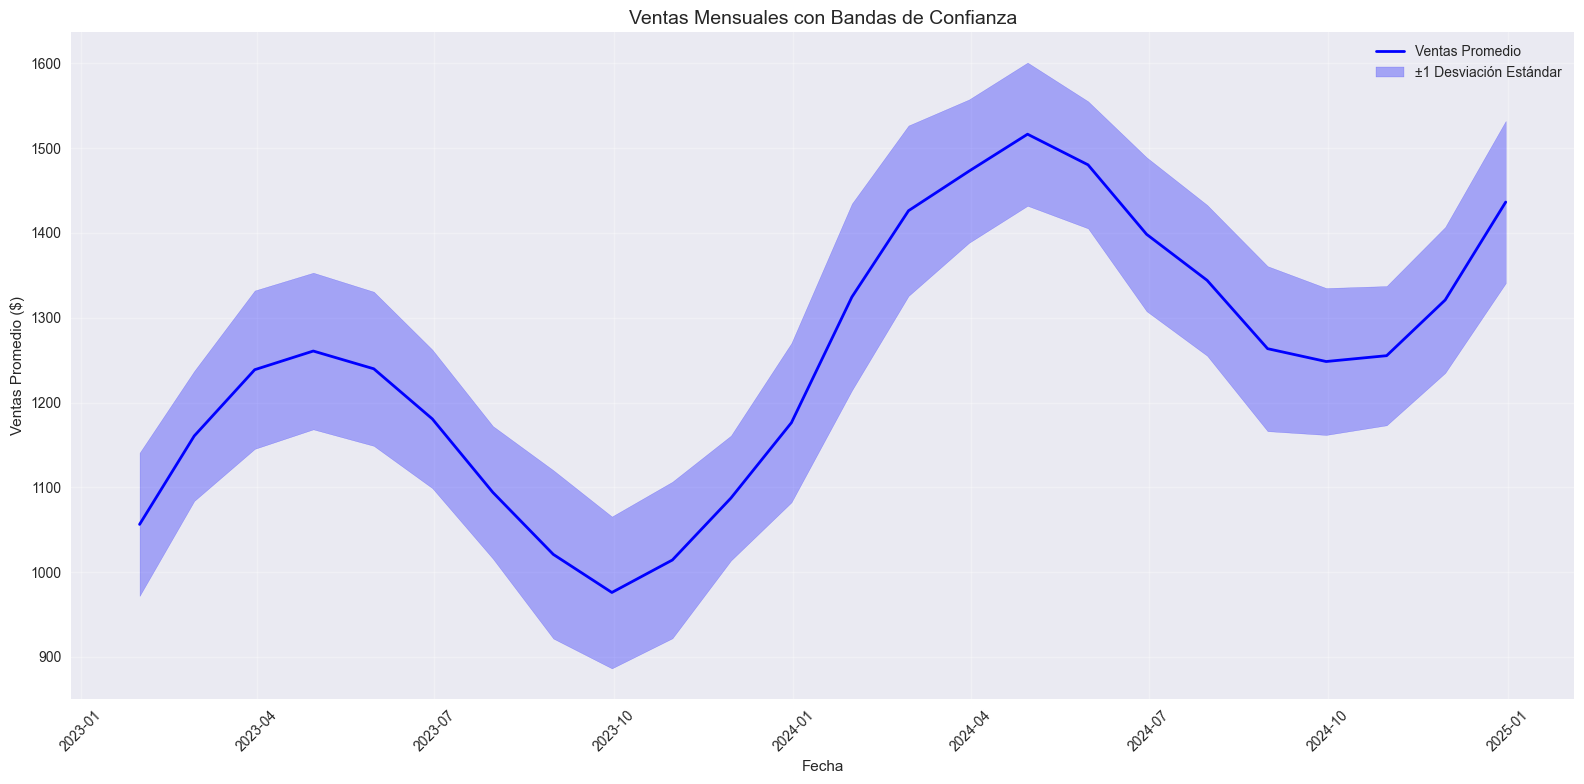

In [35]:

# 3. Gráfico con bandas de confianza
print("3. BANDAS DE CONFIANZA:")

fig, ax = plt.subplots(figsize=(16, 8))

# Calcular estadísticos móviles para bandas
ventas_mensual = ventas_indexed['ventas'].resample('M').mean()
ventas_std = ventas_indexed['ventas'].resample('M').std()

# Línea principal
ax.plot(ventas_mensual.index, ventas_mensual.values, 
       color='blue', linewidth=2, label='Ventas Promedio')

# Bandas de confianza
ax.fill_between(ventas_mensual.index, 
               ventas_mensual - ventas_std, 
               ventas_mensual + ventas_std,
               alpha=0.3, color='blue', label='±1 Desviación Estándar')

ax.set_title('Ventas Mensuales con Bandas de Confianza', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas Promedio ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4. HEATMAP TEMPORAL:


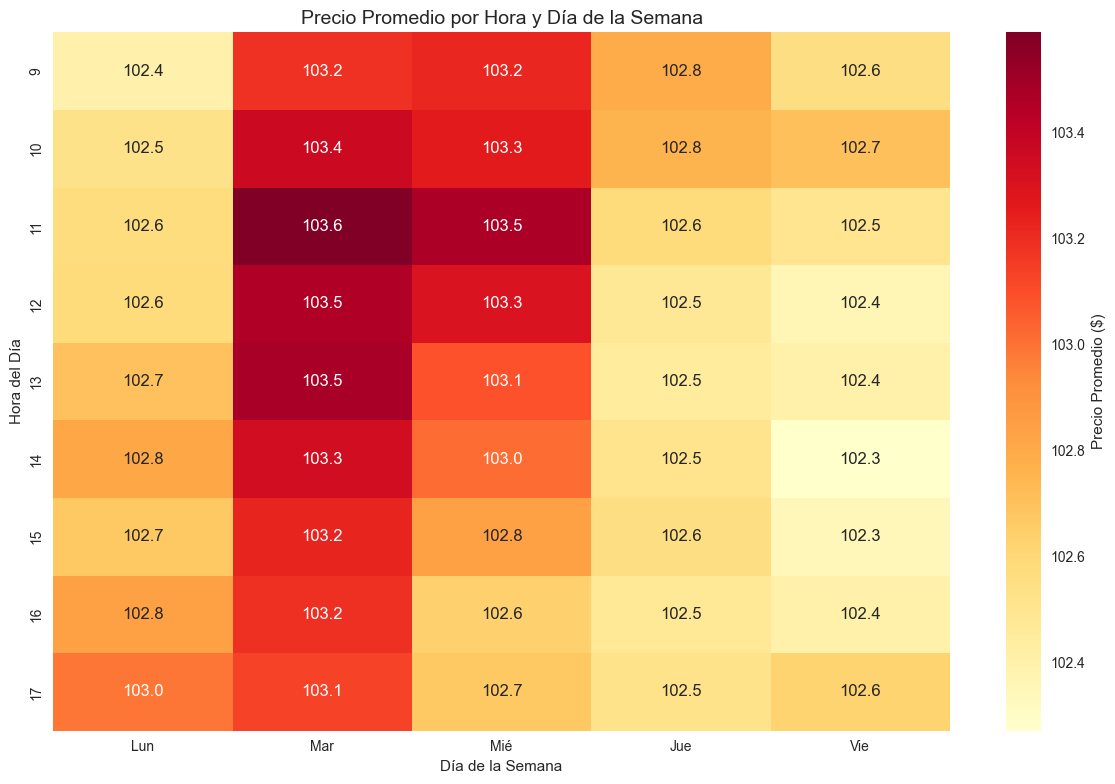

In [36]:

# 4. Heatmap temporal
print("4. HEATMAP TEMPORAL:")

# Crear matriz para heatmap (hora vs día de la semana)
datos_hora_dia = acciones_indexed.copy()
datos_hora_dia['hora'] = datos_hora_dia.index.hour
datos_hora_dia['dia_semana'] = datos_hora_dia.index.dayofweek

# Pivot table para heatmap
heatmap_data = datos_hora_dia.pivot_table(
    values='precio', 
    index='hora', 
    columns='dia_semana', 
    aggfunc='mean'
)

# Renombrar columnas
heatmap_data.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie']

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
           cbar_kws={'label': 'Precio Promedio ($)'})
plt.title('Precio Promedio por Hora y Día de la Semana', fontsize=14)
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.show()


5. MÚLTIPLES ESCALAS:


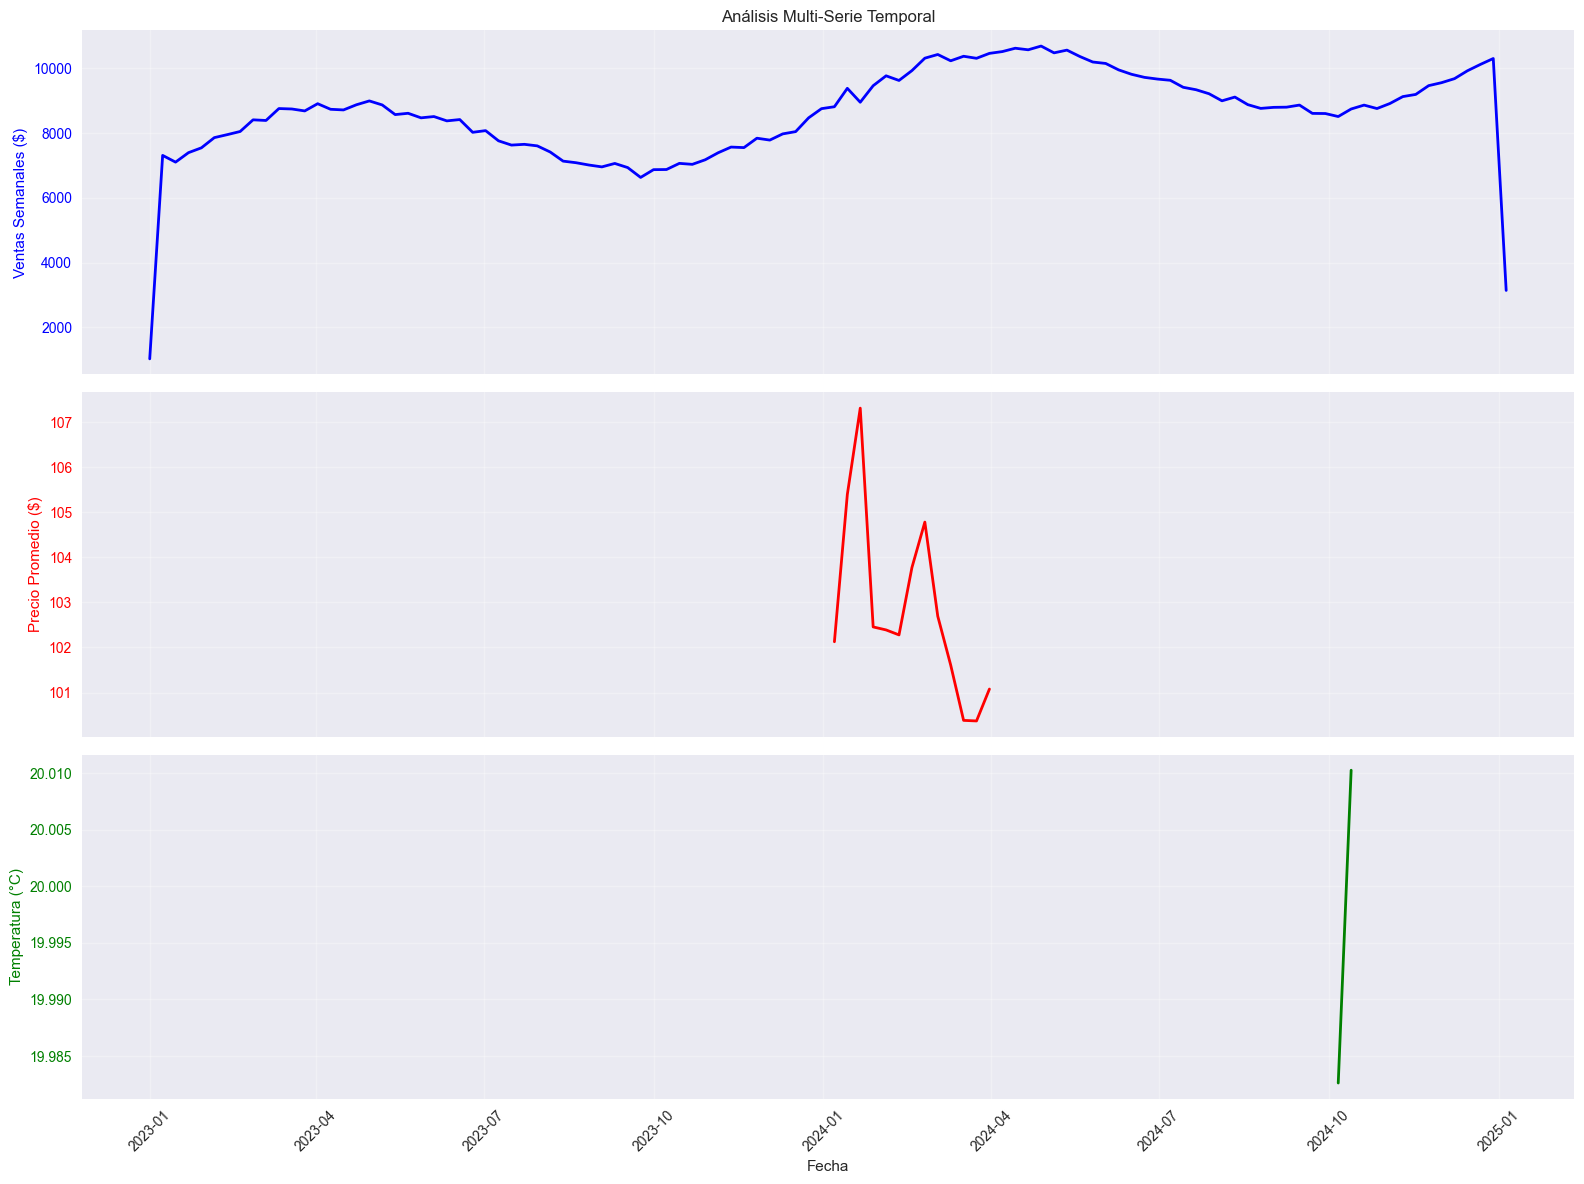

In [37]:

# 5. Subplots con diferentes escalas
print("5. MÚLTIPLES ESCALAS:")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Ventas (escala principal)
ventas_semanal = ventas_indexed['ventas'].resample('W').sum()
ax1.plot(ventas_semanal.index, ventas_semanal.values, color='blue', linewidth=2)
ax1.set_title('Análisis Multi-Serie Temporal')
ax1.set_ylabel('Ventas Semanales ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Precios (segunda escala)
precios_semanal = acciones_indexed['precio'].resample('W').mean()
ax2.plot(precios_semanal.index, precios_semanal.values, color='red', linewidth=2)
ax2.set_ylabel('Precio Promedio ($)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(True, alpha=0.3)

# Temperatura (tercera escala)
temp_semanal = sensores_indexed['temperatura'].resample('W').mean()
ax3.plot(temp_semanal.index, temp_semanal.values, color='green', linewidth=2)
ax3.set_ylabel('Temperatura (°C)', color='green')
ax3.set_xlabel('Fecha')
ax3.tick_params(axis='y', labelcolor='green')
ax3.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

# 6. Gráfico de dispersión temporal
print("6. ANÁLISIS DE CORRELACIÓN TEMPORAL:")

# Correlación entre temperatura y hora del día
plt.figure(figsize=(12, 8))
scatter_data = sensores_indexed.sample(1000)  # Muestra para visualización
plt.scatter(scatter_data.index.hour, scatter_data['temperatura'], 
           alpha=0.6, c=scatter_data['humedad'], cmap='viridis')
plt.colorbar(label='Humedad (%)')
plt.xlabel('Hora del Día')
plt.ylabel('Temperatura (°C)')
plt.title('Temperatura vs Hora del Día (Coloreado por Humedad)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualizaciones completadas. Cada tipo muestra diferentes aspectos de los datos temporales.")

## 9. Manejo de Zonas Horarias

Pandas proporciona herramientas para trabajar con diferentes zonas horarias de manera eficiente.

In [38]:
# Trabajando con zonas horarias en pandas
import pytz

print("MANEJO DE ZONAS HORARIAS")
print("=" * 30)

# 1. Crear series con zona horaria
print("1. CREAR FECHAS CON TIMEZONE:")
fechas_utc = pd.date_range('2024-01-01 08:00:00', periods=24, freq='H', tz='UTC')
print("Fechas UTC:", fechas_utc[:5])

# Crear con zona horaria específica
fechas_ny = pd.date_range('2024-01-01 08:00:00', periods=24, freq='H', tz='America/New_York')
print("Fechas Nueva York:", fechas_ny[:5])

fechas_madrid = pd.date_range('2024-01-01 08:00:00', periods=24, freq='H', tz='Europe/Madrid')
print("Fechas Madrid:", fechas_madrid[:5])

# 2. Convertir zona horaria
print("\n2. CONVERSIÓN DE ZONAS HORARIAS:")

# Serie sin timezone (naive)
fechas_naive = pd.date_range('2024-01-01 08:00:00', periods=10, freq='H')
serie_naive = pd.Series(np.random.randn(10), index=fechas_naive)
print("Serie sin timezone (naive):")
print(serie_naive.head(3))

# Localizar (asignar timezone a serie naive)
serie_utc = serie_naive.tz_localize('UTC')
print("\nSerie localizada a UTC:")
print(serie_utc.head(3))

# Convertir a otra zona horaria
serie_tokyo = serie_utc.tz_convert('Asia/Tokyo')
print("\nSerie convertida a Tokyo:")
print(serie_tokyo.head(3))

# 3. Trabajar con múltiples zonas horarias
print("\n3. MÚLTIPLES ZONAS HORARIAS:")

# Crear datos de ejemplo para diferentes ciudades
ciudades = {
    'Nueva York': 'America/New_York',
    'Londres': 'Europe/London',
    'Tokyo': 'Asia/Tokyo',
    'Sydney': 'Australia/Sydney'
}

# Crear una hora base en UTC
hora_base = pd.Timestamp('2024-01-15 12:00:00', tz='UTC')
print(f"Hora base (UTC): {hora_base}")

print("\nMisma hora en diferentes ciudades:")
for ciudad, timezone in ciudades.items():
    hora_local = hora_base.tz_convert(timezone)
    print(f"{ciudad:12}: {hora_local}")

# 4. Análisis con zonas horarias
print("\n4. ANÁLISIS CON TIMEZONE:")

# Crear datos de ejemplo con timezone
fechas_negocio = pd.date_range('2024-01-01 09:00:00', periods=100, 
                              freq='H', tz='America/New_York')
datos_negocio = pd.DataFrame({
    'timestamp': fechas_negocio,
    'ventas': np.random.exponential(1000, 100),
    'transacciones': np.random.poisson(50, 100)
})
datos_negocio.set_index('timestamp', inplace=True)

print("Datos de negocio (Timezone: NY):")
print(datos_negocio.head())

# Análisis por hora local
print("\nVentas promedio por hora local (Nueva York):")
ventas_por_hora = datos_negocio.groupby(datos_negocio.index.hour)['ventas'].mean()
print(ventas_por_hora)

# Convertir a UTC para análisis global
datos_utc = datos_negocio.tz_convert('UTC')
print("\nVentas promedio por hora UTC:")
ventas_por_hora_utc = datos_utc.groupby(datos_utc.index.hour)['ventas'].mean()
print(ventas_por_hora_utc.head())

# 5. Manejo de horario de verano
print("\n5. HORARIO DE VERANO:")

# Crear fechas que incluyan cambio de horario
fechas_dst = pd.date_range('2024-03-08 00:00:00', periods=72, 
                          freq='H', tz='America/New_York')

# Mostrar el cambio de horario de verano
print("Fechas alrededor del cambio de horario de verano:")
for i in [23, 24, 25, 26]:
    print(f"{fechas_dst[i]} - UTC: {fechas_dst[i].tz_convert('UTC')}")

# 6. Resampling con timezone
print("\n6. RESAMPLING CON TIMEZONE:")

# Resamplear manteniendo timezone
ventas_diarias_ny = datos_negocio['ventas'].resample('D').sum()
print("Ventas diarias (timezone NY):")
print(ventas_diarias_ny.head())

# Convertir a UTC y resamplear
datos_utc = datos_negocio.tz_convert('UTC')
ventas_diarias_utc = datos_utc['ventas'].resample('D').sum()
print("\nVentas diarias (timezone UTC):")
print(ventas_diarias_utc.head())

# 7. Funciones útiles para timezone
print("\n7. FUNCIONES ÚTILES:")

# Obtener información de timezone
print("Zonas horarias disponibles (muestra):")
zonas_comunes = ['UTC', 'US/Eastern', 'US/Pacific', 'Europe/London', 
                'Europe/Paris', 'Asia/Tokyo', 'Australia/Sydney']
for zona in zonas_comunes:
    try:
        tz = pytz.timezone(zona)
        print(f"{zona:15}: {tz}")
    except:
        print(f"{zona:15}: No disponible")

# Verificar si una serie tiene timezone
print(f"\n¿Serie naive tiene timezone? {serie_naive.index.tz is not None}")
print(f"¿Serie UTC tiene timezone? {serie_utc.index.tz is not None}")
print(f"Timezone de serie_utc: {serie_utc.index.tz}")

# Obtener offset de timezone
ahora_ny = pd.Timestamp.now(tz='America/New_York')
ahora_utc = pd.Timestamp.now(tz='UTC')
print(f"\nAhora en NY: {ahora_ny}")
print(f"Ahora en UTC: {ahora_utc}")
print(f"Diferencia: {ahora_ny.utcoffset()}")

print("\nManejo de timezone completado.")

MANEJO DE ZONAS HORARIAS
1. CREAR FECHAS CON TIMEZONE:
Fechas UTC: DatetimeIndex(['2024-01-01 08:00:00+00:00', '2024-01-01 09:00:00+00:00', '2024-01-01 10:00:00+00:00', '2024-01-01 11:00:00+00:00', '2024-01-01 12:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')
Fechas Nueva York: DatetimeIndex(['2024-01-01 08:00:00-05:00', '2024-01-01 09:00:00-05:00', '2024-01-01 10:00:00-05:00', '2024-01-01 11:00:00-05:00', '2024-01-01 12:00:00-05:00'], dtype='datetime64[ns, America/New_York]', freq='h')
Fechas Madrid: DatetimeIndex(['2024-01-01 08:00:00+01:00', '2024-01-01 09:00:00+01:00', '2024-01-01 10:00:00+01:00', '2024-01-01 11:00:00+01:00', '2024-01-01 12:00:00+01:00'], dtype='datetime64[ns, Europe/Madrid]', freq='h')

2. CONVERSIÓN DE ZONAS HORARIAS:
Serie sin timezone (naive):
2024-01-01 08:00:00   -0.174199
2024-01-01 09:00:00    1.176969
2024-01-01 10:00:00   -0.848222
Freq: h, dtype: float64

Serie localizada a UTC:
2024-01-01 08:00:00+00:00   -0.174199
2024-01-01 09:00:00+00:00    1.

## 10. Tratamiento de Datos Faltantes en Series Temporales

El manejo de datos faltantes en series temporales requiere técnicas especializadas debido a la naturaleza secuencial de los datos.

DATOS FALTANTES EN SERIES TEMPORALES
1. CREAR SERIE CON DATOS FALTANTES:
Serie original: 100 valores
Serie con faltantes: 20 valores faltantes
Porcentaje faltante: 20.0%

2. ANÁLISIS DE PATRONES FALTANTES:
Total faltantes: 20
Porcentaje: 20.0%
Gaps consecutivos: [1, 1, 1, 1, 5, 1, 2, 1, 2, 1, 1, 1, 1, 1]
Gap máximo: 5 días
Número de gaps: 14

3. MÉTODOS DE IMPUTACIÓN:
Forward fill - últimos 5 valores:
2024-04-05    91.527882
2024-04-06    92.178267
2024-04-07    93.551041
2024-04-08    93.827679
2024-04-09    93.618696
Freq: D, dtype: float64

Backward fill - primeros 5 valores:
2024-01-01    98.552039
2024-01-02    98.552039
2024-01-03    98.984582
2024-01-04    98.432308
2024-01-05    97.843927
Freq: D, dtype: float64

Interpolación lineal completada
Interpolación temporal completada
Interpolación polinómica completada
Interpolación spline completada

4. COMPARACIÓN VISUAL:


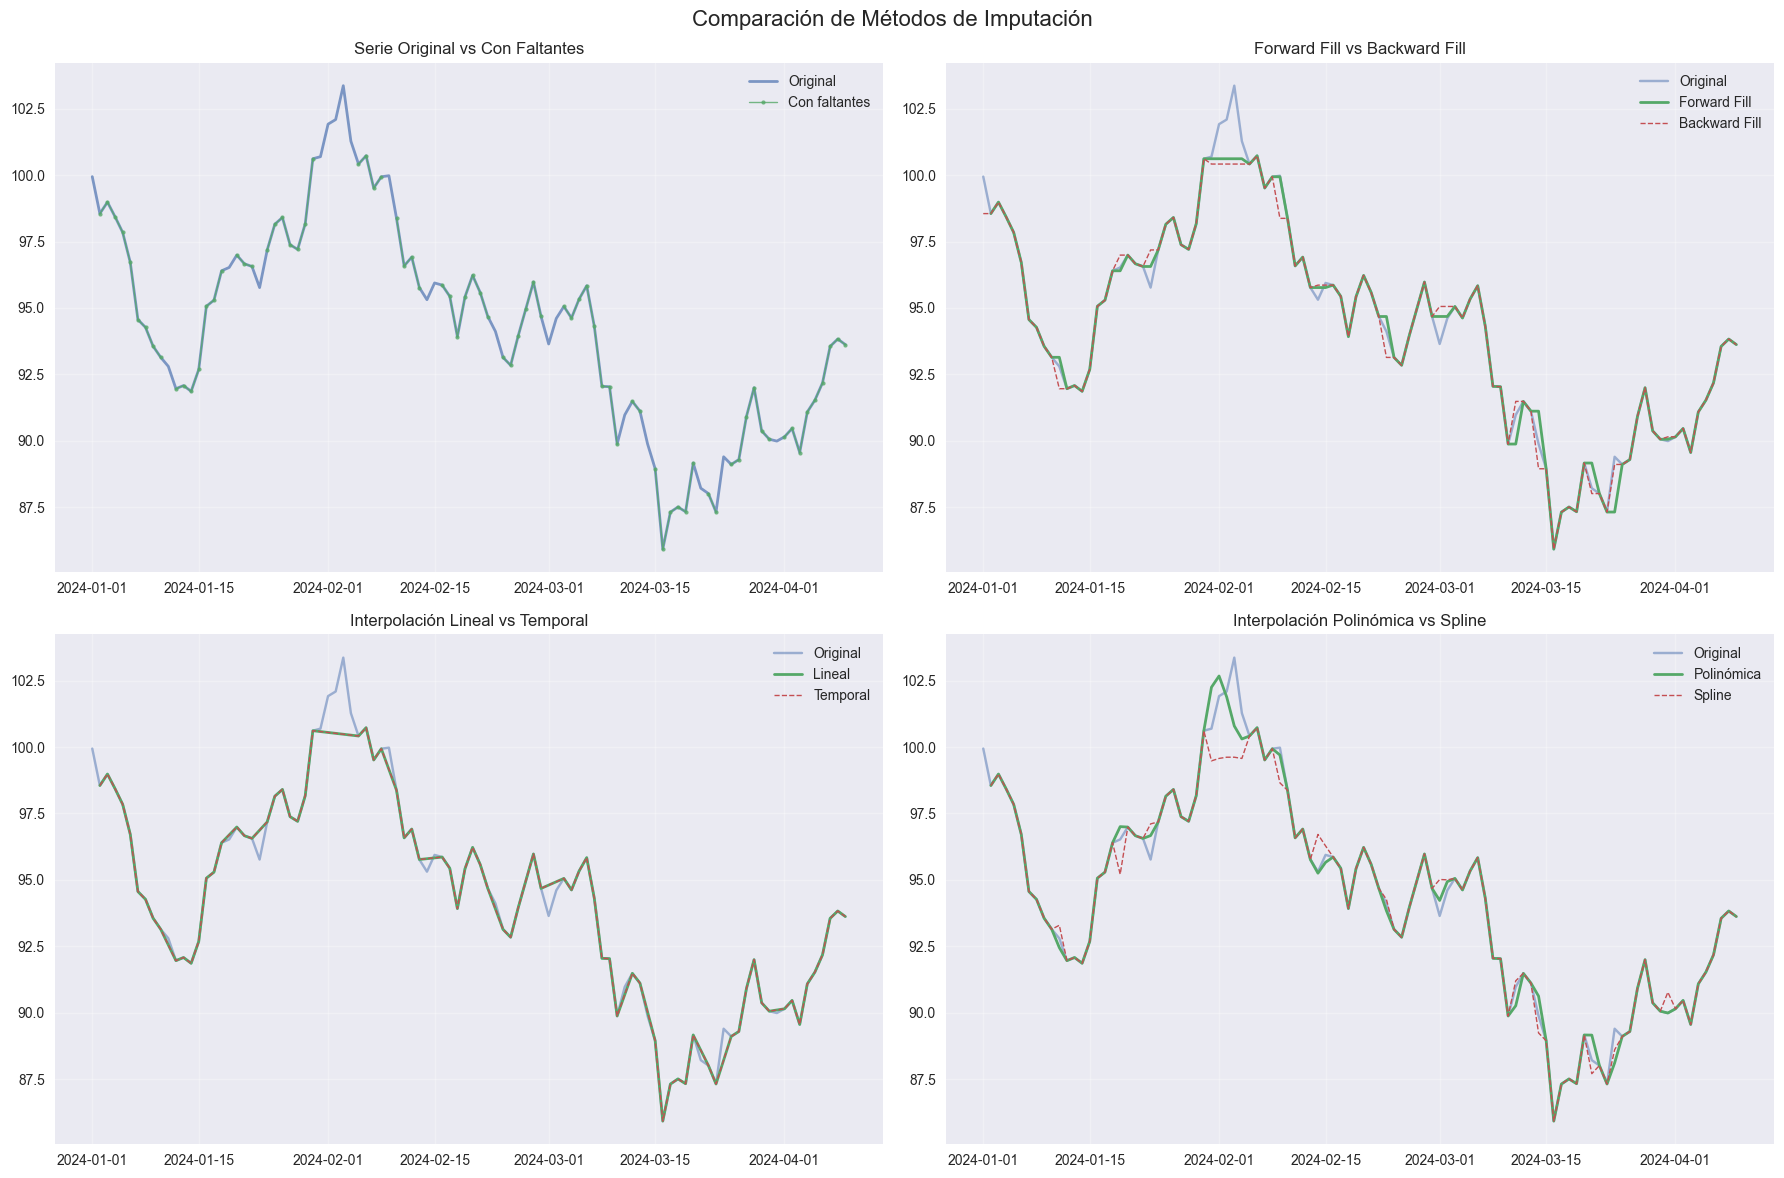

In [40]:
# Tratamiento especializado de datos faltantes en series temporales
from scipy import interpolate

print("DATOS FALTANTES EN SERIES TEMPORALES")
print("=" * 40)

# 1. Crear serie temporal con datos faltantes
print("1. CREAR SERIE CON DATOS FALTANTES:")

# Serie temporal regular
fechas_completas = pd.date_range('2024-01-01', periods=100, freq='D')
valores = np.cumsum(np.random.randn(100)) + 100  # Random walk

# Introducir datos faltantes de manera realística
serie_completa = pd.Series(valores, index=fechas_completas)
np.random.seed(42)

# Diferentes tipos de faltantes
indices_faltantes = np.random.choice(serie_completa.index, size=15, replace=False)
serie_con_faltantes = serie_completa.copy()
serie_con_faltantes.loc[indices_faltantes] = np.nan

# Crear gaps consecutivos (más realista)
serie_con_faltantes.iloc[30:35] = np.nan  # Gap de 5 días
serie_con_faltantes.iloc[60:62] = np.nan  # Gap de 2 días

print(f"Serie original: {len(serie_completa)} valores")
print(f"Serie con faltantes: {serie_con_faltantes.isna().sum()} valores faltantes")
print(f"Porcentaje faltante: {serie_con_faltantes.isna().mean()*100:.1f}%")

# 2. Detección y análisis de patrones faltantes
print("\n2. ANÁLISIS DE PATRONES FALTANTES:")

def analizar_faltantes_temporales(serie):
    """Analiza patrones de datos faltantes en series temporales"""
    
    # Estadísticas básicas
    total_faltantes = serie.isna().sum()
    porcentaje_faltante = serie.isna().mean() * 100
    
    # Encontrar gaps consecutivos
    faltantes_mask = serie.isna()
    gaps = []
    gap_actual = 0
    
    for i, es_faltante in enumerate(faltantes_mask):
        if es_faltante:
            gap_actual += 1
        else:
            if gap_actual > 0:
                gaps.append(gap_actual)
                gap_actual = 0
    
    # Último gap si termina con faltantes
    if gap_actual > 0:
        gaps.append(gap_actual)
    
    # Distribución temporal de faltantes
    faltantes_por_mes = serie.groupby(serie.index.month).apply(lambda x: x.isna().sum())
    
    return {
        'total_faltantes': total_faltantes,
        'porcentaje': porcentaje_faltante,
        'gaps_consecutivos': gaps,
        'gap_maximo': max(gaps) if gaps else 0,
        'num_gaps': len(gaps),
        'faltantes_por_mes': faltantes_por_mes
    }

analisis = analizar_faltantes_temporales(serie_con_faltantes)
print(f"Total faltantes: {analisis['total_faltantes']}")
print(f"Porcentaje: {analisis['porcentaje']:.1f}%")
print(f"Gaps consecutivos: {analisis['gaps_consecutivos']}")
print(f"Gap máximo: {analisis['gap_maximo']} días")
print(f"Número de gaps: {analisis['num_gaps']}")

# 3. Métodos de imputación temporal
print("\n3. MÉTODOS DE IMPUTACIÓN:")

# Forward fill (llevado hacia adelante)
serie_ffill = serie_con_faltantes.fillna(method='ffill')
print("Forward fill - últimos 5 valores:")
print(serie_ffill.tail())

# Backward fill (llevado hacia atrás)
serie_bfill = serie_con_faltantes.fillna(method='bfill')
print("\nBackward fill - primeros 5 valores:")
print(serie_bfill.head())

# Interpolación lineal
serie_interp_linear = serie_con_faltantes.interpolate(method='linear')
print("\nInterpolación lineal completada")

# Interpolación con tiempo (considera las fechas reales)
serie_interp_time = serie_con_faltantes.interpolate(method='time')
print("Interpolación temporal completada")

# Interpolación polinómica
serie_interp_poly = serie_con_faltantes.interpolate(method='polynomial', order=2)
print("Interpolación polinómica completada")

# Interpolación spline
serie_interp_spline = serie_con_faltantes.interpolate(method='spline', order=3)
print("Interpolación spline completada")

# 4. Comparación visual de métodos
print("\n4. COMPARACIÓN VISUAL:")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparación de Métodos de Imputación', fontsize=16)

# Datos originales vs con faltantes
axes[0, 0].plot(serie_completa.index, serie_completa.values, 
               label='Original', alpha=0.7, linewidth=2)
axes[0, 0].plot(serie_con_faltantes.index, serie_con_faltantes.values, 
               label='Con faltantes', alpha=0.8, linewidth=1, marker='o', markersize=3)
axes[0, 0].set_title('Serie Original vs Con Faltantes')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Forward/Backward fill
axes[0, 1].plot(serie_completa.index, serie_completa.values, 
               label='Original', alpha=0.5)
axes[0, 1].plot(serie_ffill.index, serie_ffill.values, 
               label='Forward Fill', linewidth=2)
axes[0, 1].plot(serie_bfill.index, serie_bfill.values, 
               label='Backward Fill', linewidth=1, linestyle='--')
axes[0, 1].set_title('Forward Fill vs Backward Fill')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Interpolaciones
axes[1, 0].plot(serie_completa.index, serie_completa.values, 
               label='Original', alpha=0.5)
axes[1, 0].plot(serie_interp_linear.index, serie_interp_linear.values, 
               label='Lineal', linewidth=2)
axes[1, 0].plot(serie_interp_time.index, serie_interp_time.values, 
               label='Temporal', linewidth=1, linestyle='--')
axes[1, 0].set_title('Interpolación Lineal vs Temporal')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Interpolaciones avanzadas
axes[1, 1].plot(serie_completa.index, serie_completa.values, 
               label='Original', alpha=0.5)
axes[1, 1].plot(serie_interp_poly.index, serie_interp_poly.values, 
               label='Polinómica', linewidth=2)
axes[1, 1].plot(serie_interp_spline.index, serie_interp_spline.values, 
               label='Spline', linewidth=1, linestyle='--')
axes[1, 1].set_title('Interpolación Polinómica vs Spline')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



5. EVALUACIÓN DE MÉTODOS:
Evaluación de métodos (solo en posiciones originalmente faltantes):
------------------------------------------------------------
Forward Fill         | MAE: 0.77 | RMSE: 1.10 | MAPE: 0.8%
Interpolación Lineal | MAE: 0.59 | RMSE: 0.94 | MAPE: 0.6%
Interpolación Temporal | MAE: 0.59 | RMSE: 0.94 | MAPE: 0.6%
Interpolación Polinómica | MAE: 0.75 | RMSE: 1.00 | MAPE: 0.8%
Interpolación Spline | MAE: 1.02 | RMSE: 1.34 | MAPE: 1.1%

6. IMPUTACIÓN ESTACIONAL:


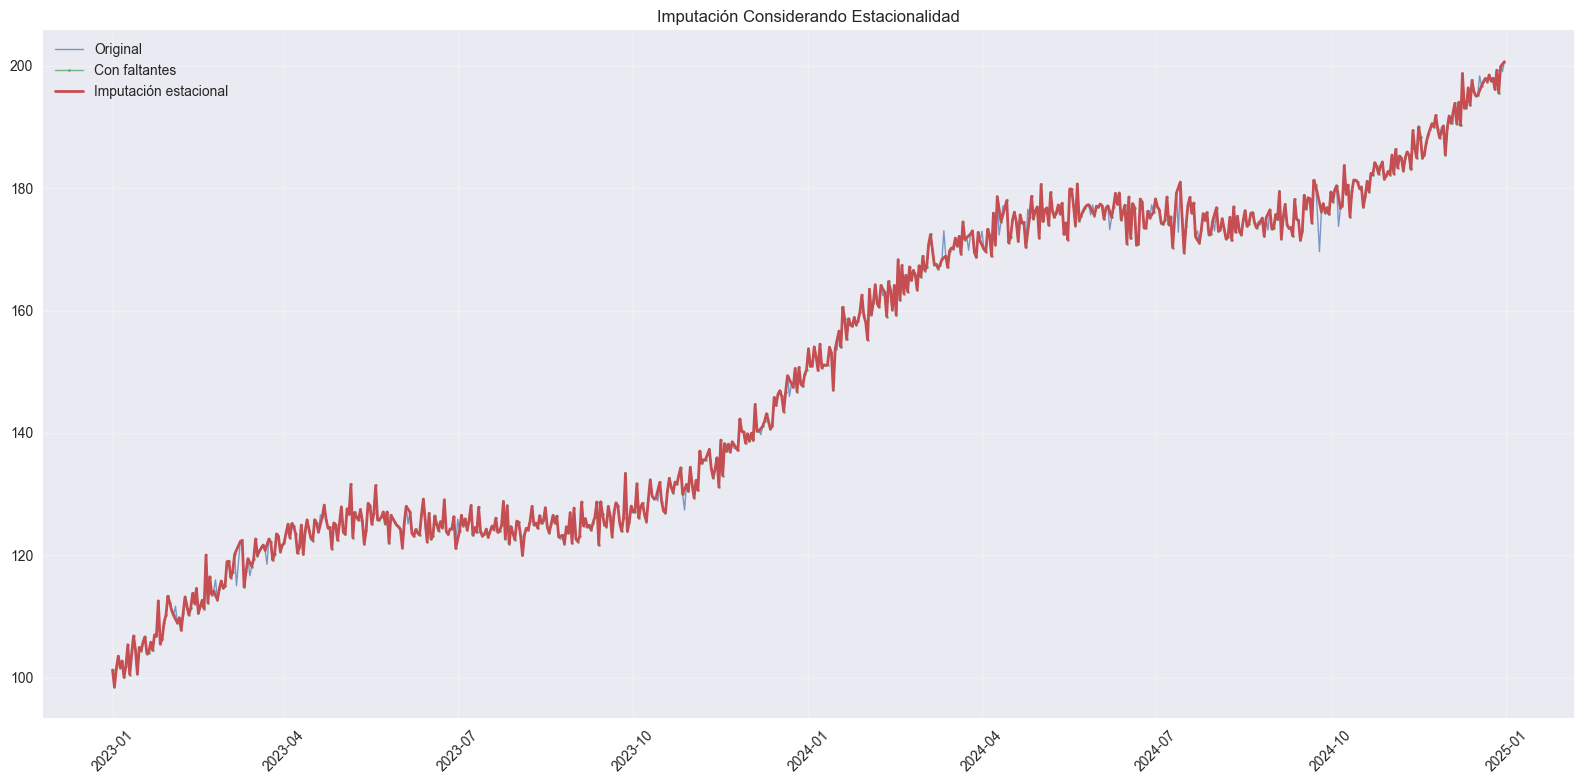

Tratamiento de datos faltantes en series temporales completado.


In [41]:

# 5. Métricas de evaluación
print("\n5. EVALUACIÓN DE MÉTODOS:")

def evaluar_imputacion(serie_original, serie_imputada, indices_faltantes):
    """Evalúa la calidad de la imputación"""
    valores_reales = serie_original.loc[indices_faltantes]
    valores_imputados = serie_imputada.loc[indices_faltantes]
    
    # Eliminar NaN si aún existen
    mask_validos = ~(valores_reales.isna() | valores_imputados.isna())
    valores_reales = valores_reales[mask_validos]
    valores_imputados = valores_imputados[mask_validos]
    
    if len(valores_reales) == 0:
        return {'mae': np.nan, 'rmse': np.nan, 'mape': np.nan}
    
    # Métricas
    mae = np.mean(np.abs(valores_reales - valores_imputados))
    rmse = np.sqrt(np.mean((valores_reales - valores_imputados) ** 2))
    mape = np.mean(np.abs((valores_reales - valores_imputados) / valores_reales)) * 100
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

# Evaluar diferentes métodos
metodos = {
    'Forward Fill': serie_ffill,
    'Interpolación Lineal': serie_interp_linear,
    'Interpolación Temporal': serie_interp_time,
    'Interpolación Polinómica': serie_interp_poly,
    'Interpolación Spline': serie_interp_spline
}

print("Evaluación de métodos (solo en posiciones originalmente faltantes):")
print("-" * 60)
for nombre, serie_metodo in metodos.items():
    metricas = evaluar_imputacion(serie_completa, serie_metodo, indices_faltantes)
    print(f"{nombre:20} | MAE: {metricas['mae']:.2f} | RMSE: {metricas['rmse']:.2f} | MAPE: {metricas['mape']:.1f}%")

# 6. Imputación con información estacional
print("\n6. IMPUTACIÓN ESTACIONAL:")

# Crear serie con patrón estacional
fechas_est = pd.date_range('2023-01-01', '2024-12-31', freq='D')
tendencia = np.linspace(100, 200, len(fechas_est))
estacional = 10 * np.sin(2 * np.pi * np.arange(len(fechas_est)) / 365.25)
ruido = np.random.normal(0, 2, len(fechas_est))
serie_estacional = pd.Series(tendencia + estacional + ruido, index=fechas_est)

# Introducir faltantes
np.random.seed(42)
indices_falt_est = np.random.choice(serie_estacional.index, size=50, replace=False)
serie_est_faltantes = serie_estacional.copy()
serie_est_faltantes.loc[indices_falt_est] = np.nan

# Imputación considerando estacionalidad
def imputacion_estacional(serie, periodo=365):
    """Imputación usando valores del mismo período del año anterior/posterior"""
    serie_imputada = serie.copy()
    
    for idx in serie.index[serie.isna()]:
        # Buscar mismo día del año anterior/posterior
        try:
            # Año anterior
            idx_anterior = idx - pd.DateOffset(days=periodo)
            if idx_anterior in serie.index and not serie.loc[idx_anterior].isna():
                serie_imputada.loc[idx] = serie.loc[idx_anterior]
                continue
            
            # Año posterior
            idx_posterior = idx + pd.DateOffset(days=periodo)
            if idx_posterior in serie.index and not serie.loc[idx_posterior].isna():
                serie_imputada.loc[idx] = serie.loc[idx_posterior]
                continue
            
            # Promedio de ventana alrededor del mismo día
            ventana_inicio = idx - pd.DateOffset(days=7)
            ventana_fin = idx + pd.DateOffset(days=7)
            ventana_data = serie.loc[ventana_inicio:ventana_fin]
            if not ventana_data.dropna().empty:
                serie_imputada.loc[idx] = ventana_data.mean()
                
        except:
            # Si falla, usar interpolación lineal
            serie_imputada = serie_imputada.interpolate()
            break
    
    return serie_imputada

serie_est_imputada = imputacion_estacional(serie_est_faltantes)

# Visualizar resultado estacional
plt.figure(figsize=(16, 8))
plt.plot(serie_estacional.index, serie_estacional.values, 
         label='Original', alpha=0.7, linewidth=1)
plt.plot(serie_est_faltantes.index, serie_est_faltantes.values, 
         label='Con faltantes', alpha=0.8, linewidth=1, marker='o', markersize=2)
plt.plot(serie_est_imputada.index, serie_est_imputada.values, 
         label='Imputación estacional', linewidth=2)
plt.title('Imputación Considerando Estacionalidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Tratamiento de datos faltantes en series temporales completado.")

## 11. Casos Prácticos con Series Temporales

Aplicación de las técnicas aprendidas en escenarios reales de análisis de datos.

In [43]:
# Casos prácticos integrando todas las técnicas aprendidas

print("CASOS PRÁCTICOS CON SERIES TEMPORALES")
print("=" * 40)

# CASO 1: Análisis de ventas de e-commerce
print("CASO 1: ANÁLISIS DE VENTAS E-COMMERCE")
print("-" * 40)

# Simular datos realistas de e-commerce
np.random.seed(42)
fechas_ecommerce = pd.date_range('2022-01-01', '2024-12-31', freq='D')

# Crear ventas con tendencia, estacionalidad y eventos especiales
base_ventas = 1000
tendencia = np.linspace(0, 500, len(fechas_ecommerce))  # Crecimiento

# Estacionalidad anual (más ventas en noviembre-diciembre)
estacional_anual = 200 * np.sin(2 * np.pi * (fechas_ecommerce.dayofyear - 320) / 365)

# Estacionalidad semanal (menos ventas en fin de semana)
estacional_semanal = -100 * ((fechas_ecommerce.dayofweek >= 5).astype(int))

# Eventos especiales (Black Friday, Navidad, etc.)
eventos = np.zeros(len(fechas_ecommerce))
for fecha in fechas_ecommerce:
    # Black Friday (último viernes de noviembre)
    if fecha.month == 11 and fecha.dayofweek == 4 and fecha.day >= 22:
        eventos[fechas_ecommerce.get_loc(fecha)] = 800
    # Cyber Monday
    elif fecha.month == 11 and fecha.dayofweek == 0 and fecha.day >= 25:
        eventos[fechas_ecommerce.get_loc(fecha)] = 600
    # Navidad
    elif fecha.month == 12 and fecha.day == 25:
        eventos[fechas_ecommerce.get_loc(fecha)] = 400

# Ruido
ruido = np.random.normal(0, 50, len(fechas_ecommerce))

# Serie final
ventas_ecommerce = base_ventas + tendencia + estacional_anual + estacional_semanal + eventos + ruido
ventas_ecommerce = np.maximum(ventas_ecommerce, 0)  # No ventas negativas

df_ecommerce = pd.DataFrame({
    'fecha': fechas_ecommerce,
    'ventas': ventas_ecommerce,
    'categoria': np.random.choice(['Electrónicos', 'Ropa', 'Hogar', 'Libros'], len(fechas_ecommerce)),
    'canal': np.random.choice(['Web', 'Móvil', 'Marketplace'], len(fechas_ecommerce), p=[0.5, 0.3, 0.2])
})
df_ecommerce.set_index('fecha', inplace=True)

print("1. Resumen de datos e-commerce:")
print(f"Período: {df_ecommerce.index.min()} a {df_ecommerce.index.max()}")
print(f"Total días: {len(df_ecommerce)}")
print(f"Ventas promedio diarias: ${df_ecommerce['ventas'].mean():.0f}")
print(f"Ventas máximas: ${df_ecommerce['ventas'].max():.0f}")


CASOS PRÁCTICOS CON SERIES TEMPORALES
CASO 1: ANÁLISIS DE VENTAS E-COMMERCE
----------------------------------------
1. Resumen de datos e-commerce:
Período: 2022-01-01 00:00:00 a 2024-12-31 00:00:00
Total días: 1096
Ventas promedio diarias: $1229
Ventas máximas: $2305



2. Análisis temporal:
Crecimiento promedio mensual: 1.2%
Mes con mayores ventas: diciembre ($1406)

Ventas promedio por día de la semana:
Lun: $1259
Mar: $1256
Mié: $1247
Jue: $1251
Vie: $1277
Sáb: $1155
Dom: $1156


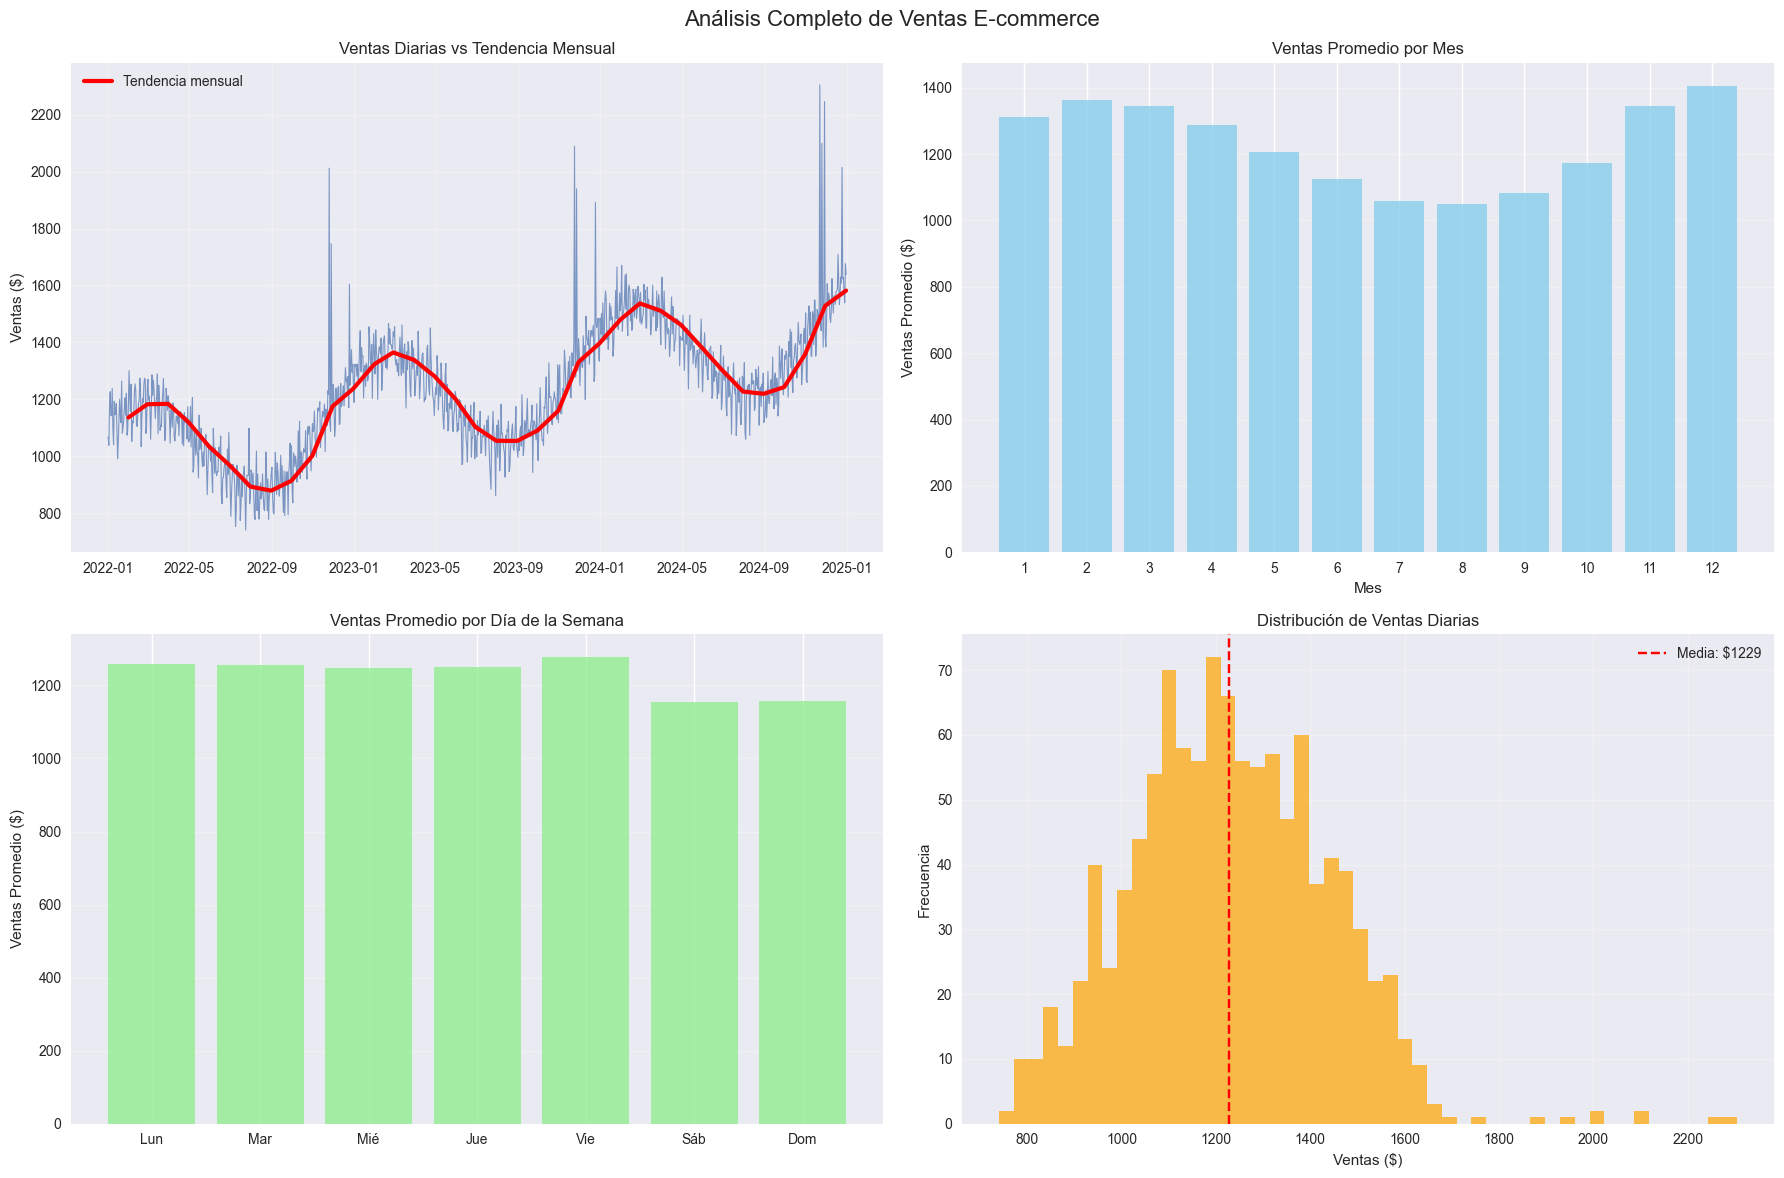

In [45]:
# Análisis temporal completo
print("\n2. Análisis temporal:")

# Tendencia general
ventas_mensuales = df_ecommerce['ventas'].resample('M').mean()
print(f"Crecimiento promedio mensual: {ventas_mensuales.pct_change().mean()*100:.1f}%")

# Estacionalidad
ventas_por_mes = df_ecommerce.groupby(df_ecommerce.index.month)['ventas'].mean()
mes_mayor_venta = ventas_por_mes.idxmax()
print(f"Mes con mayores ventas: {calendar.month_name[mes_mayor_venta]} (${ventas_por_mes.max():.0f})")

# Patrones semanales
ventas_por_dia_semana = df_ecommerce.groupby(df_ecommerce.index.dayofweek)['ventas'].mean()
dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
print("\nVentas promedio por día de la semana:")
for i, dia in enumerate(dias_semana):
    print(f"{dia}: ${ventas_por_dia_semana.iloc[i]:.0f}")

# Visualización integral
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Completo de Ventas E-commerce', fontsize=16)

# Serie temporal completa
axes[0, 0].plot(df_ecommerce.index, df_ecommerce['ventas'], alpha=0.7, linewidth=0.8)
axes[0, 0].plot(ventas_mensuales.index, ventas_mensuales.values, 
               color='red', linewidth=3, label='Tendencia mensual')
axes[0, 0].set_title('Ventas Diarias vs Tendencia Mensual')
axes[0, 0].set_ylabel('Ventas ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Estacionalidad mensual
axes[0, 1].bar(range(1, 13), ventas_por_mes.values, color='skyblue', alpha=0.8)
axes[0, 1].set_title('Ventas Promedio por Mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Ventas Promedio ($)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Patrones semanales
axes[1, 0].bar(dias_semana, ventas_por_dia_semana.values, color='lightgreen', alpha=0.8)
axes[1, 0].set_title('Ventas Promedio por Día de la Semana')
axes[1, 0].set_ylabel('Ventas Promedio ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Distribución de ventas
axes[1, 1].hist(df_ecommerce['ventas'], bins=50, alpha=0.7, color='orange')
axes[1, 1].axvline(df_ecommerce['ventas'].mean(), color='red', linestyle='--', 
                  label=f'Media: ${df_ecommerce["ventas"].mean():.0f}')
axes[1, 1].set_title('Distribución de Ventas Diarias')
axes[1, 1].set_xlabel('Ventas ($)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



CASO 2: ANÁLISIS DE SENSORES IoT
----------------------------------------
1. Resumen datos IoT:
Período: 2024-01-01 00:00:00 a 2024-01-07 00:00:00
Frecuencia: 1729 lecturas en 7 días
Promedio temperatura: 20.0°C
Promedio humedad: 69.9%

2. Correlaciones:
             temperatura   humedad   presion
temperatura     1.000000 -0.837087  0.022451
humedad        -0.837087  1.000000 -0.004128
presion         0.022451 -0.004128  1.000000

3. Promedios por período del día:
             temperatura    humedad      presion
periodo_dia                                     
Madrugada      15.719864  73.249963  1015.134676
Mañana         26.220238  65.117794  1015.403421
Tarde          23.683031  66.791292  1015.609726
Noche          14.120732  74.689430  1015.642150

4. Detección de anomalías:
Anomalías detectadas en temperatura: 0


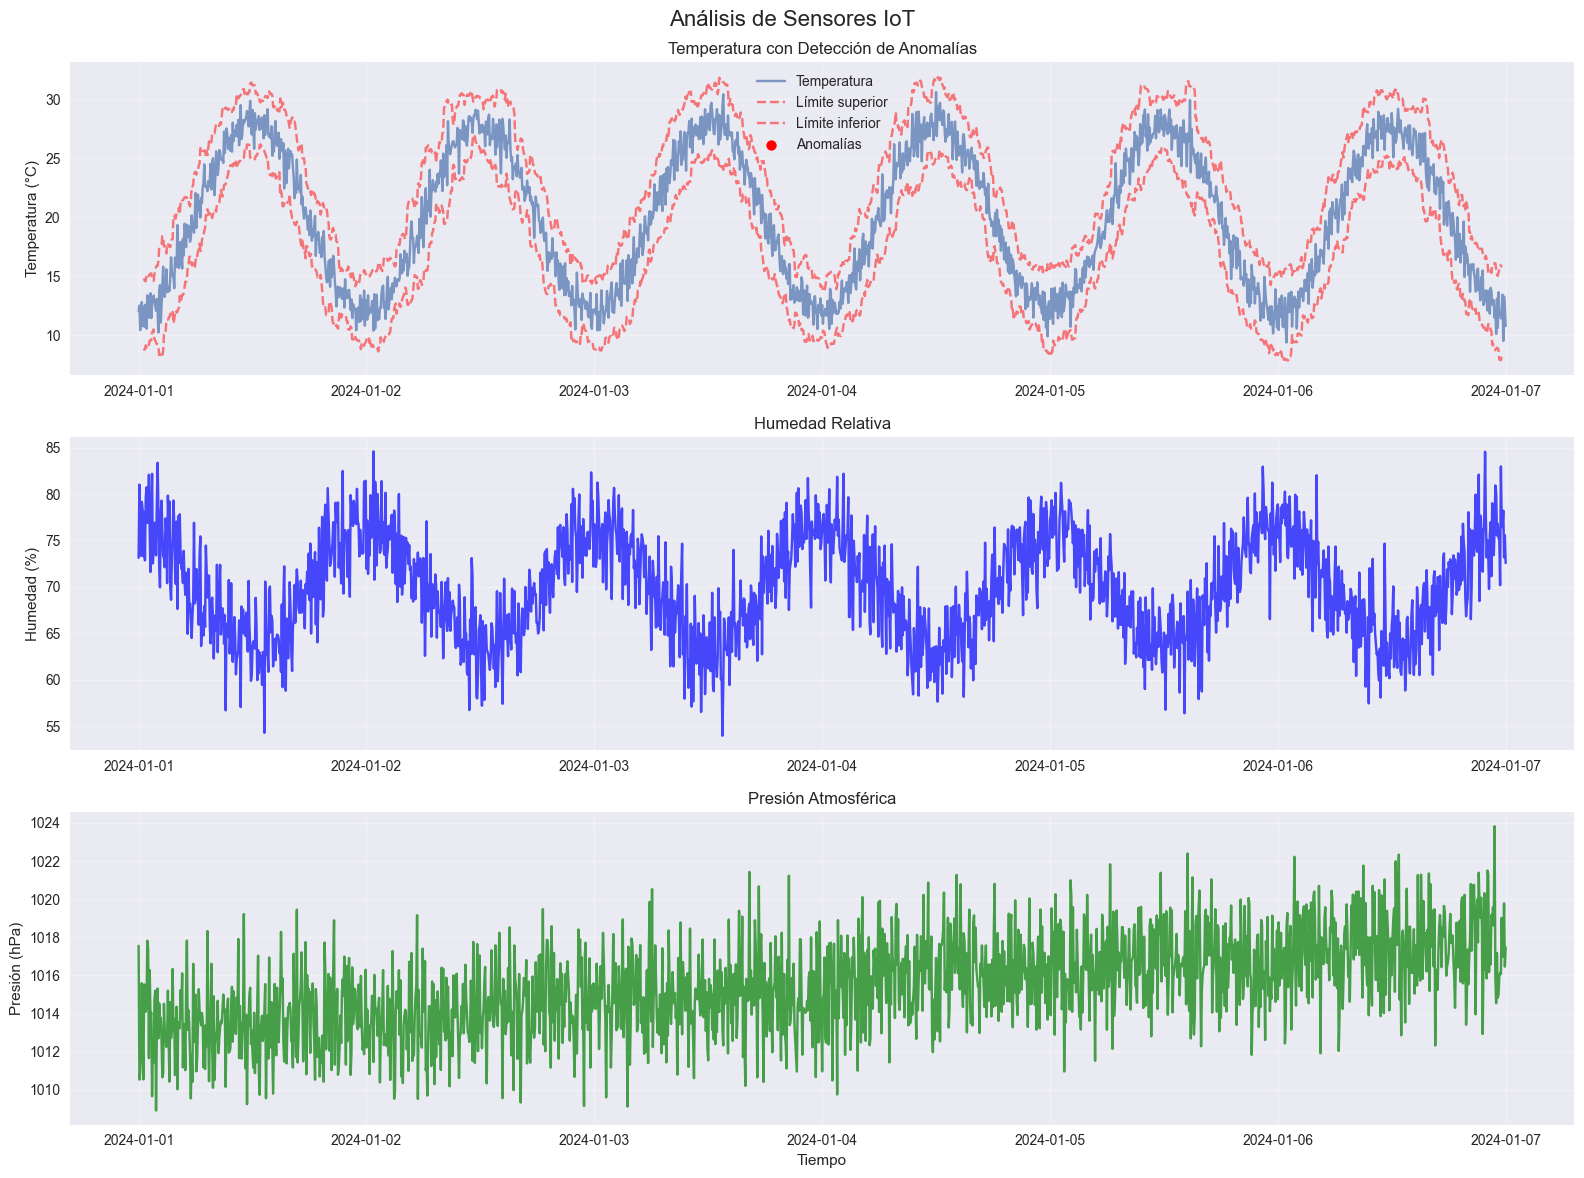

In [46]:
# CASO 2: Análisis de sensores IoT
print("\nCASO 2: ANÁLISIS DE SENSORES IoT")
print("-" * 40)

# Simular datos de sensores con múltiples variables
fechas_iot = pd.date_range('2024-01-01', '2024-01-07', freq='5T')  # Cada 5 minutos por una semana

# Temperatura con patrón diario
hora_decimal = fechas_iot.hour + fechas_iot.minute/60
temp_base = 20 + 8 * np.sin(2 * np.pi * (hora_decimal - 6) / 24)  # Pico a las 14:00
temperatura = temp_base + np.random.normal(0, 1, len(fechas_iot))

# Humedad inversa a temperatura
humedad = 70 - 0.8 * (temperatura - 20) + np.random.normal(0, 3, len(fechas_iot))
humedad = np.clip(humedad, 30, 90)

# Presión con tendencia lenta
presion_base = np.linspace(1013, 1018, len(fechas_iot))
presion = presion_base + np.random.normal(0, 2, len(fechas_iot))

df_iot = pd.DataFrame({
    'timestamp': fechas_iot,
    'temperatura': temperatura,
    'humedad': humedad,
    'presion': presion,
    'sensor_id': np.random.choice(['SENSOR_01', 'SENSOR_02', 'SENSOR_03'], len(fechas_iot))
})
df_iot.set_index('timestamp', inplace=True)

print("1. Resumen datos IoT:")
print(f"Período: {df_iot.index.min()} a {df_iot.index.max()}")
print(f"Frecuencia: {len(df_iot)} lecturas en 7 días")
print(f"Promedio temperatura: {df_iot['temperatura'].mean():.1f}°C")
print(f"Promedio humedad: {df_iot['humedad'].mean():.1f}%")

# Análisis de correlaciones temporales
print("\n2. Correlaciones:")
correlaciones = df_iot[['temperatura', 'humedad', 'presion']].corr()
print(correlaciones)

# Análisis por períodos del día
df_iot['periodo_dia'] = pd.cut(df_iot.index.hour, 
                              bins=[0, 6, 12, 18, 24], 
                              labels=['Madrugada', 'Mañana', 'Tarde', 'Noche'],
                              include_lowest=True)

print("\n3. Promedios por período del día:")
resumen_periodos = df_iot.groupby('periodo_dia')[['temperatura', 'humedad', 'presion']].mean()
print(resumen_periodos)

# Detección de anomalías simples
print("\n4. Detección de anomalías:")

def detectar_anomalias_iot(serie, ventana=12, umbral=3):
    """Detecta anomalías usando rolling statistics"""
    rolling_mean = serie.rolling(window=ventana, center=True).mean()
    rolling_std = serie.rolling(window=ventana, center=True).std()
    
    limite_superior = rolling_mean + umbral * rolling_std
    limite_inferior = rolling_mean - umbral * rolling_std
    
    anomalias = (serie > limite_superior) | (serie < limite_inferior)
    return anomalias, limite_superior, limite_inferior

# Detectar anomalías en temperatura
anomalias_temp, limite_sup, limite_inf = detectar_anomalias_iot(df_iot['temperatura'])
print(f"Anomalías detectadas en temperatura: {anomalias_temp.sum()}")

# Visualización IoT
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Análisis de Sensores IoT', fontsize=16)

# Temperatura con anomalías
axes[0].plot(df_iot.index, df_iot['temperatura'], alpha=0.7, label='Temperatura')
axes[0].plot(df_iot.index, limite_sup, 'r--', alpha=0.5, label='Límite superior')
axes[0].plot(df_iot.index, limite_inf, 'r--', alpha=0.5, label='Límite inferior')
axes[0].scatter(df_iot.index[anomalias_temp], df_iot['temperatura'][anomalias_temp], 
               color='red', s=50, label='Anomalías')
axes[0].set_title('Temperatura con Detección de Anomalías')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Humedad
axes[1].plot(df_iot.index, df_iot['humedad'], color='blue', alpha=0.7)
axes[1].set_title('Humedad Relativa')
axes[1].set_ylabel('Humedad (%)')
axes[1].grid(True, alpha=0.3)

# Presión
axes[2].plot(df_iot.index, df_iot['presion'], color='green', alpha=0.7)
axes[2].set_title('Presión Atmosférica')
axes[2].set_xlabel('Tiempo')
axes[2].set_ylabel('Presión (hPa)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



CASO 3: ANÁLISIS FINANCIERO
------------------------------
1. Resumen financiero:
Período: 2023-01-02 00:00:00 a 2024-12-31 00:00:00
Días de trading: 522

2. Métricas por activo:
TECH_STOCK:
  Retorno total: 6.0%
  Volatilidad anual: 31.0%
STABLE_BOND:
  Retorno total: 23.6%
  Volatilidad anual: 7.8%
COMMODITY:
  Retorno total: 179.1%
  Volatilidad anual: 48.5%

3. Correlación de retornos:
                     TECH_STOCK_retorno  STABLE_BOND_retorno  COMMODITY_retorno
TECH_STOCK_retorno             1.000000            -0.009390          -0.023807
STABLE_BOND_retorno           -0.009390             1.000000          -0.002293
COMMODITY_retorno             -0.023807            -0.002293           1.000000


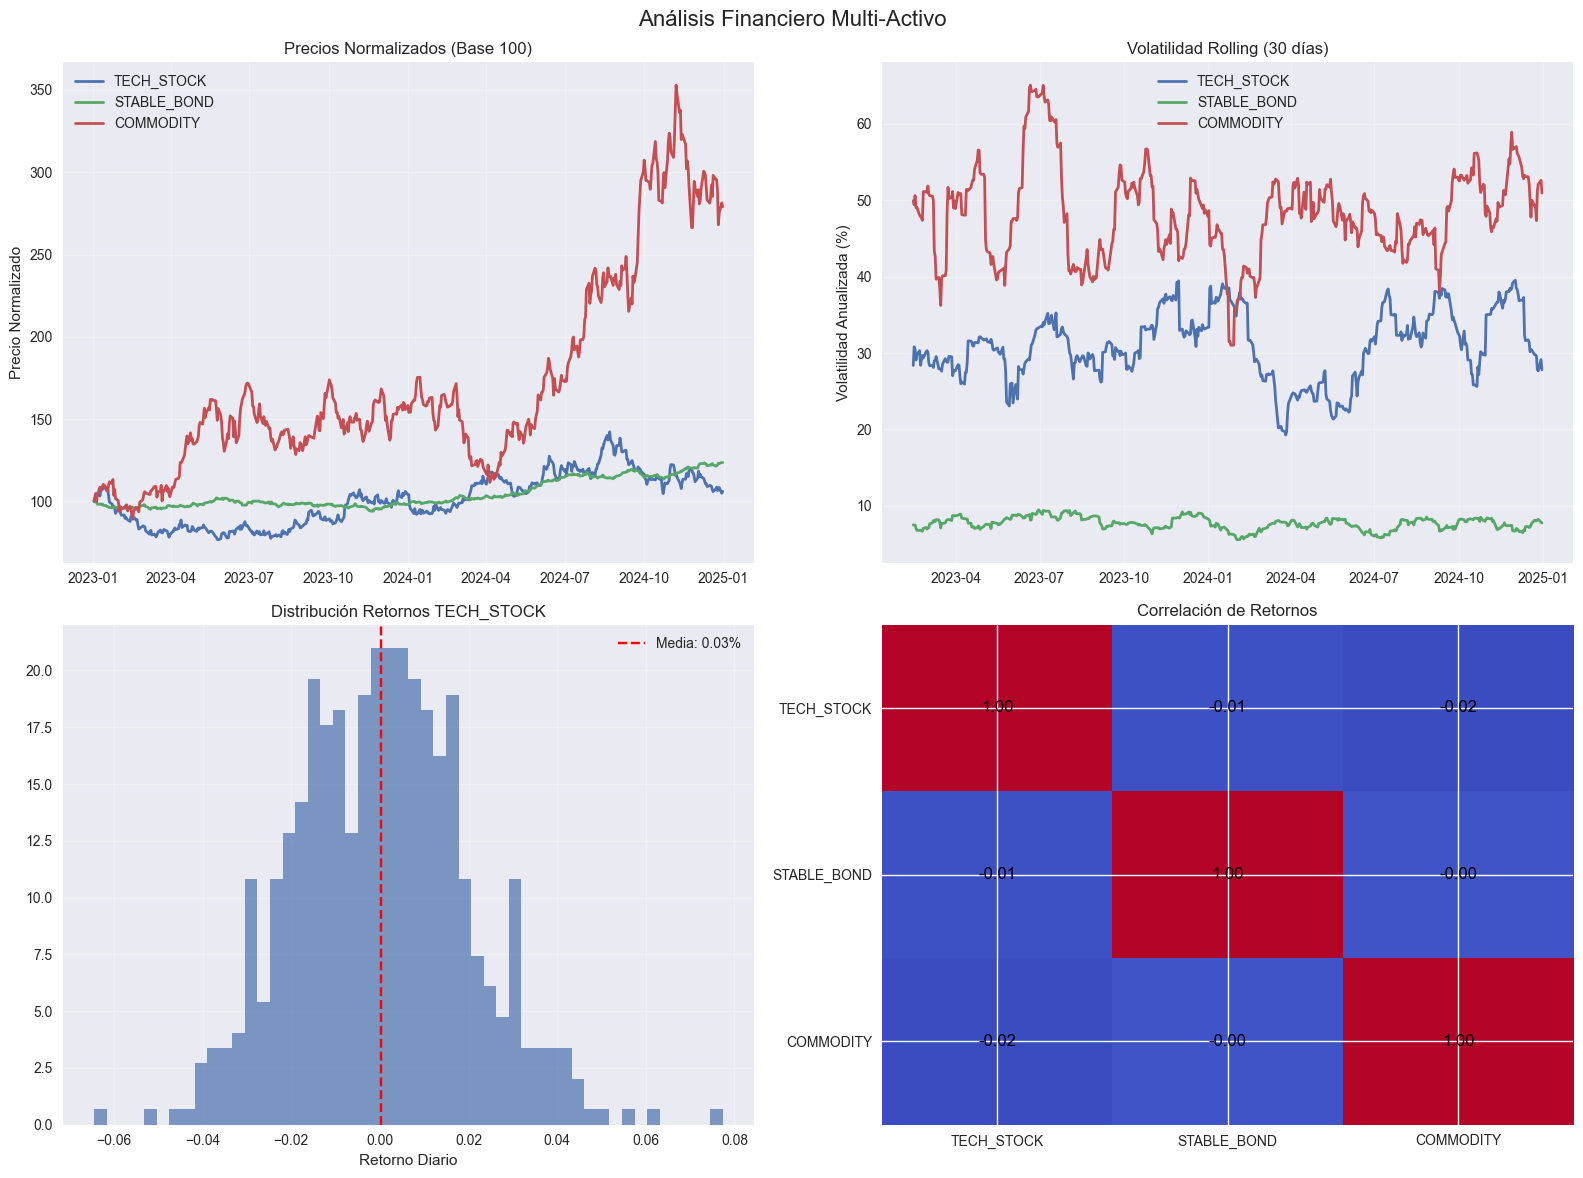

In [47]:

# CASO 3: Análisis financiero con múltiples activos
print("\nCASO 3: ANÁLISIS FINANCIERO")
print("-" * 30)

# Simular precios de múltiples activos
fechas_fin = pd.date_range('2023-01-01', '2024-12-31', freq='D')
fechas_fin = fechas_fin[fechas_fin.dayofweek < 5]  # Solo días hábiles

# Simular 3 activos con diferentes características
np.random.seed(42)
activos = {
    'TECH_STOCK': {
        'precio_inicial': 100,
        'volatilidad': 0.02,
        'tendencia': 0.0003
    },
    'STABLE_BOND': {
        'precio_inicial': 1000,
        'volatilidad': 0.005,
        'tendencia': 0.0001
    },
    'COMMODITY': {
        'precio_inicial': 50,
        'volatilidad': 0.03,
        'tendencia': 0.0002
    }
}

df_financiero = pd.DataFrame(index=fechas_fin)

for activo, params in activos.items():
    # Generar random walk con tendencia
    returns = np.random.normal(params['tendencia'], params['volatilidad'], len(fechas_fin))
    prices = [params['precio_inicial']]
    
    for ret in returns[1:]:
        prices.append(prices[-1] * (1 + ret))
    
    df_financiero[f'{activo}_precio'] = prices
    df_financiero[f'{activo}_retorno'] = df_financiero[f'{activo}_precio'].pct_change()

print("1. Resumen financiero:")
print(f"Período: {df_financiero.index.min()} a {df_financiero.index.max()}")
print(f"Días de trading: {len(df_financiero)}")

# Calcular métricas financieras
print("\n2. Métricas por activo:")
for activo in activos.keys():
    precio_col = f'{activo}_precio'
    retorno_col = f'{activo}_retorno'
    
    precio_inicial = df_financiero[precio_col].iloc[0]
    precio_final = df_financiero[precio_col].iloc[-1]
    retorno_total = (precio_final / precio_inicial - 1) * 100
    volatilidad_anual = df_financiero[retorno_col].std() * np.sqrt(252) * 100
    
    print(f"{activo}:")
    print(f"  Retorno total: {retorno_total:.1f}%")
    print(f"  Volatilidad anual: {volatilidad_anual:.1f}%")

# Matriz de correlaciones
print("\n3. Correlación de retornos:")
retornos_cols = [col for col in df_financiero.columns if 'retorno' in col]
correlacion_retornos = df_financiero[retornos_cols].corr()
print(correlacion_retornos)

# Visualización financiera
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Financiero Multi-Activo', fontsize=16)

# Precios normalizados
precios_norm = df_financiero[[col for col in df_financiero.columns if 'precio' in col]].copy()
for col in precios_norm.columns:
    precios_norm[col] = precios_norm[col] / precios_norm[col].iloc[0] * 100

for col in precios_norm.columns:
    axes[0, 0].plot(precios_norm.index, precios_norm[col], 
                   label=col.replace('_precio', ''), linewidth=2)
axes[0, 0].set_title('Precios Normalizados (Base 100)')
axes[0, 0].set_ylabel('Precio Normalizado')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Volatilidad rolling
vol_window = 30
for activo in activos.keys():
    retorno_col = f'{activo}_retorno'
    vol_rolling = df_financiero[retorno_col].rolling(vol_window).std() * np.sqrt(252) * 100
    axes[0, 1].plot(df_financiero.index, vol_rolling, 
                   label=activo, linewidth=2)
axes[0, 1].set_title(f'Volatilidad Rolling ({vol_window} días)')
axes[0, 1].set_ylabel('Volatilidad Anualizada (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribución de retornos
retorno_tech = df_financiero['TECH_STOCK_retorno'].dropna()
axes[1, 0].hist(retorno_tech, bins=50, alpha=0.7, density=True)
axes[1, 0].axvline(retorno_tech.mean(), color='red', linestyle='--', 
                  label=f'Media: {retorno_tech.mean()*100:.2f}%')
axes[1, 0].set_title('Distribución Retornos TECH_STOCK')
axes[1, 0].set_xlabel('Retorno Diario')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Heatmap correlaciones
im = axes[1, 1].imshow(correlacion_retornos.values, cmap='coolwarm', aspect='auto')
axes[1, 1].set_xticks(range(len(correlacion_retornos.columns)))
axes[1, 1].set_yticks(range(len(correlacion_retornos.columns)))
axes[1, 1].set_xticklabels([col.replace('_retorno', '') for col in correlacion_retornos.columns])
axes[1, 1].set_yticklabels([col.replace('_retorno', '') for col in correlacion_retornos.columns])
axes[1, 1].set_title('Correlación de Retornos')

# Agregar valores en el heatmap
for i in range(len(correlacion_retornos.columns)):
    for j in range(len(correlacion_retornos.columns)):
        axes[1, 1].text(j, i, f'{correlacion_retornos.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


In [48]:

print("\nTodos los casos prácticos completados.")
print("Estas técnicas pueden aplicarse a:")
print("- Análisis de KPIs de negocio")
print("- Monitoreo de sistemas y performance")
print("- Análisis de tendencias de mercado")
print("- Optimización de procesos temporales")
print("- Detección de patrones y anomalías")


Todos los casos prácticos completados.
Estas técnicas pueden aplicarse a:
- Análisis de KPIs de negocio
- Monitoreo de sistemas y performance
- Análisis de tendencias de mercado
- Optimización de procesos temporales
- Detección de patrones y anomalías



2. Análisis temporal:
Crecimiento promedio mensual: 1.2%
Mes con mayores ventas: diciembre ($1406)

Ventas promedio por día de la semana:
Lun: $1259
Mar: $1256
Mié: $1247
Jue: $1251
Vie: $1277
Sáb: $1155
Dom: $1156


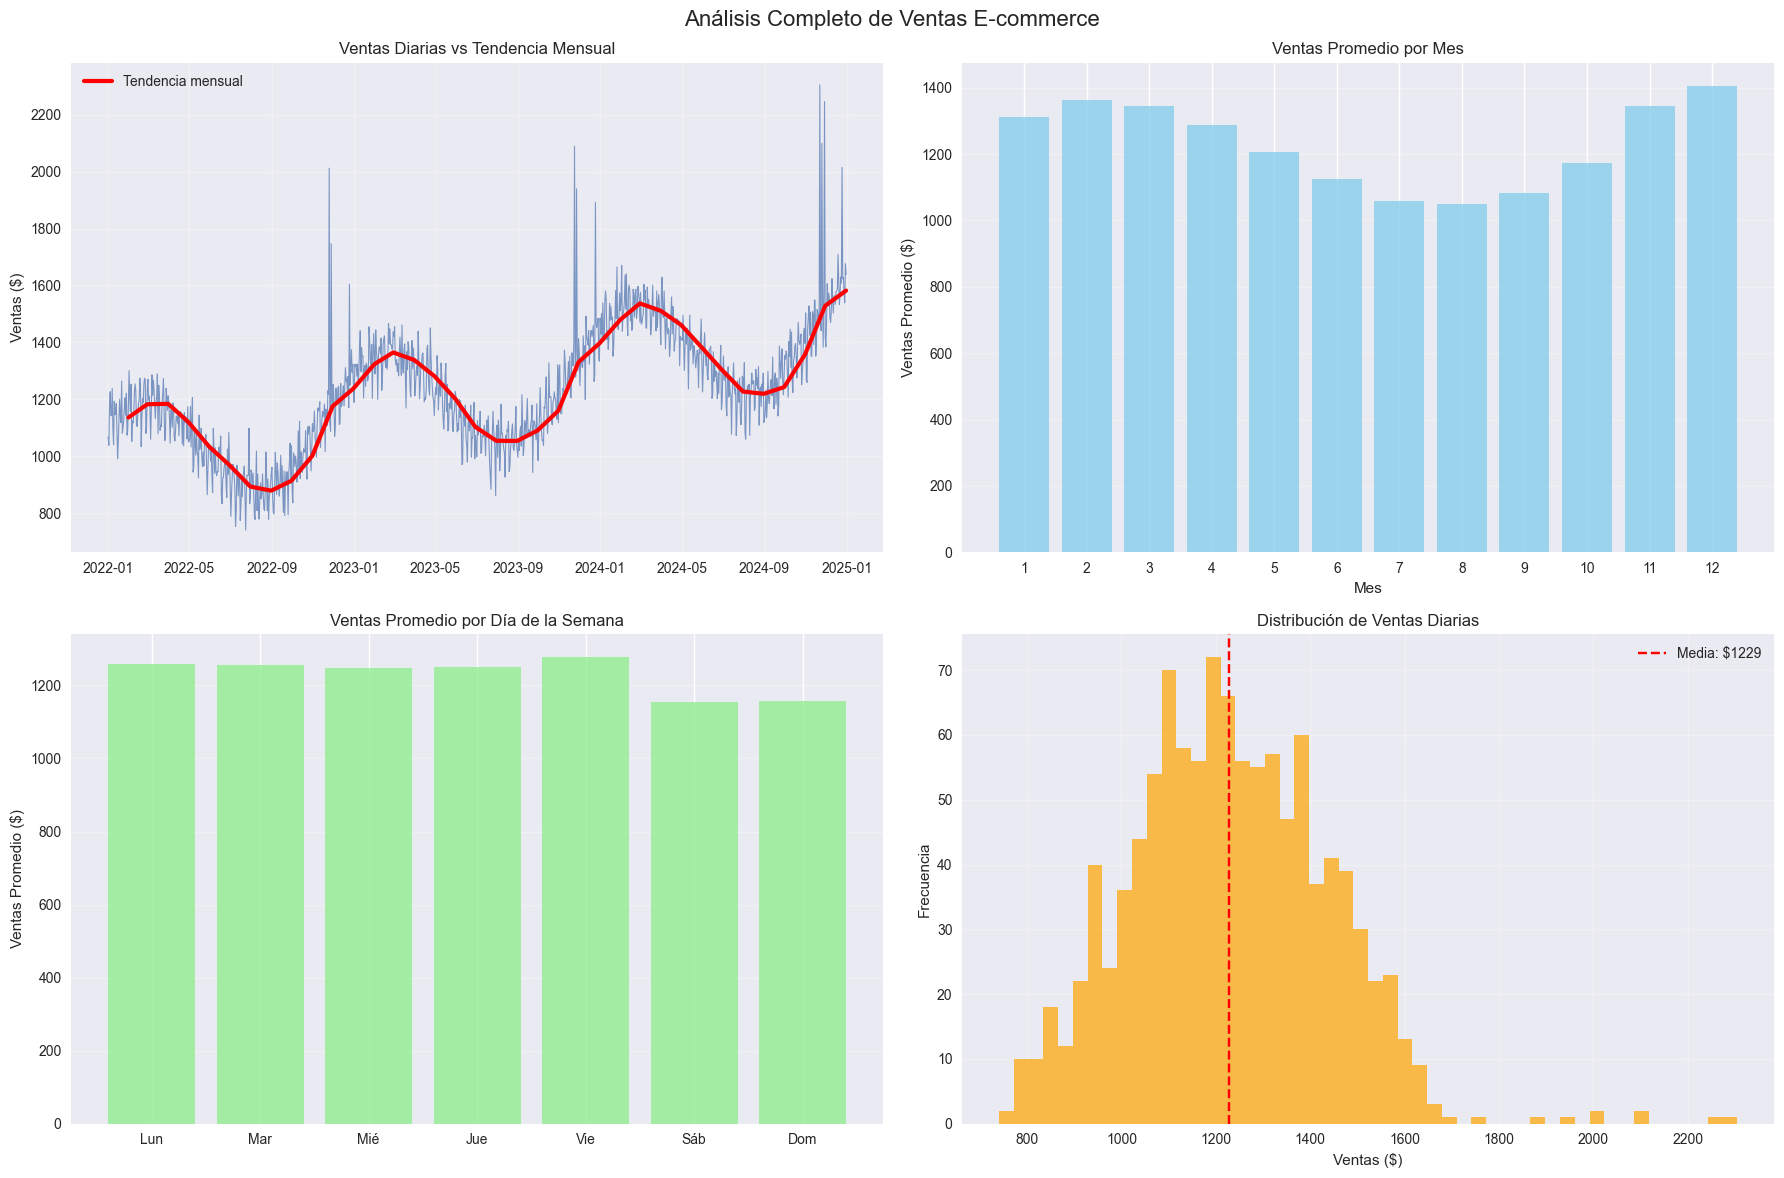

In [49]:

# Análisis temporal completo
print("\n2. Análisis temporal:")

# Tendencia general
ventas_mensuales = df_ecommerce['ventas'].resample('M').mean()
print(f"Crecimiento promedio mensual: {ventas_mensuales.pct_change().mean()*100:.1f}%")

# Estacionalidad
ventas_por_mes = df_ecommerce.groupby(df_ecommerce.index.month)['ventas'].mean()
mes_mayor_venta = ventas_por_mes.idxmax()
print(f"Mes con mayores ventas: {calendar.month_name[mes_mayor_venta]} (${ventas_por_mes.max():.0f})")

# Patrones semanales
ventas_por_dia_semana = df_ecommerce.groupby(df_ecommerce.index.dayofweek)['ventas'].mean()
dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
print("\nVentas promedio por día de la semana:")
for i, dia in enumerate(dias_semana):
    print(f"{dia}: ${ventas_por_dia_semana.iloc[i]:.0f}")

# Visualización integral
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis Completo de Ventas E-commerce', fontsize=16)

# Serie temporal completa
axes[0, 0].plot(df_ecommerce.index, df_ecommerce['ventas'], alpha=0.7, linewidth=0.8)
axes[0, 0].plot(ventas_mensuales.index, ventas_mensuales.values, 
               color='red', linewidth=3, label='Tendencia mensual')
axes[0, 0].set_title('Ventas Diarias vs Tendencia Mensual')
axes[0, 0].set_ylabel('Ventas ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Estacionalidad mensual
axes[0, 1].bar(range(1, 13), ventas_por_mes.values, color='skyblue', alpha=0.8)
axes[0, 1].set_title('Ventas Promedio por Mes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Ventas Promedio ($)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Patrones semanales
axes[1, 0].bar(dias_semana, ventas_por_dia_semana.values, color='lightgreen', alpha=0.8)
axes[1, 0].set_title('Ventas Promedio por Día de la Semana')
axes[1, 0].set_ylabel('Ventas Promedio ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Distribución de ventas
axes[1, 1].hist(df_ecommerce['ventas'], bins=50, alpha=0.7, color='orange')
axes[1, 1].axvline(df_ecommerce['ventas'].mean(), color='red', linestyle='--', 
                  label=f'Media: ${df_ecommerce["ventas"].mean():.0f}')
axes[1, 1].set_title('Distribución de Ventas Diarias')
axes[1, 1].set_xlabel('Ventas ($)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



CASO 2: ANÁLISIS DE SENSORES IoT
----------------------------------------
1. Resumen datos IoT:
Período: 2024-01-01 00:00:00 a 2024-01-07 00:00:00
Frecuencia: 1729 lecturas en 7 días
Promedio temperatura: 20.0°C
Promedio humedad: 69.9%

2. Correlaciones:
             temperatura   humedad   presion
temperatura     1.000000 -0.837087  0.022451
humedad        -0.837087  1.000000 -0.004128
presion         0.022451 -0.004128  1.000000

3. Promedios por período del día:
             temperatura    humedad      presion
periodo_dia                                     
Madrugada      15.719864  73.249963  1015.134676
Mañana         26.220238  65.117794  1015.403421
Tarde          23.683031  66.791292  1015.609726
Noche          14.120732  74.689430  1015.642150

4. Detección de anomalías:
Anomalías detectadas en temperatura: 0


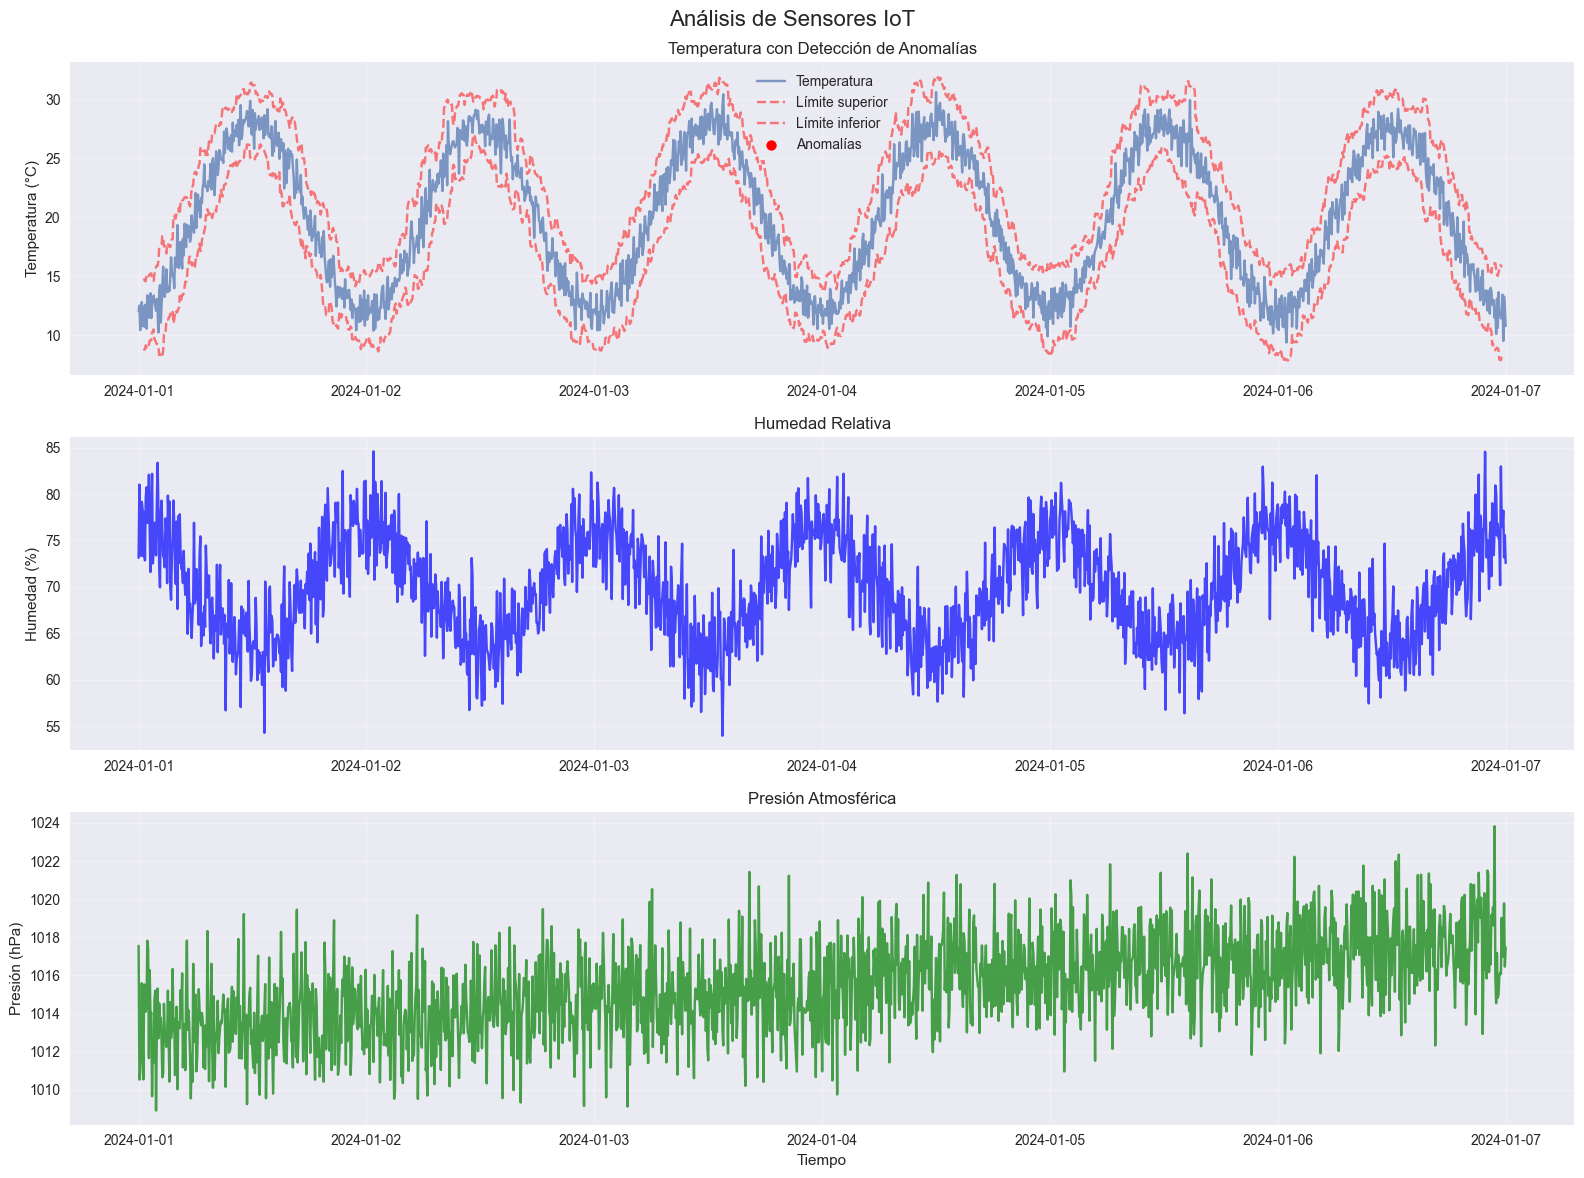

In [50]:

# CASO 2: Análisis de sensores IoT
print("\nCASO 2: ANÁLISIS DE SENSORES IoT")
print("-" * 40)

# Simular datos de sensores con múltiples variables
fechas_iot = pd.date_range('2024-01-01', '2024-01-07', freq='5T')  # Cada 5 minutos por una semana

# Temperatura con patrón diario
hora_decimal = fechas_iot.hour + fechas_iot.minute/60
temp_base = 20 + 8 * np.sin(2 * np.pi * (hora_decimal - 6) / 24)  # Pico a las 14:00
temperatura = temp_base + np.random.normal(0, 1, len(fechas_iot))

# Humedad inversa a temperatura
humedad = 70 - 0.8 * (temperatura - 20) + np.random.normal(0, 3, len(fechas_iot))
humedad = np.clip(humedad, 30, 90)

# Presión con tendencia lenta
presion_base = np.linspace(1013, 1018, len(fechas_iot))
presion = presion_base + np.random.normal(0, 2, len(fechas_iot))

df_iot = pd.DataFrame({
    'timestamp': fechas_iot,
    'temperatura': temperatura,
    'humedad': humedad,
    'presion': presion,
    'sensor_id': np.random.choice(['SENSOR_01', 'SENSOR_02', 'SENSOR_03'], len(fechas_iot))
})
df_iot.set_index('timestamp', inplace=True)

print("1. Resumen datos IoT:")
print(f"Período: {df_iot.index.min()} a {df_iot.index.max()}")
print(f"Frecuencia: {len(df_iot)} lecturas en 7 días")
print(f"Promedio temperatura: {df_iot['temperatura'].mean():.1f}°C")
print(f"Promedio humedad: {df_iot['humedad'].mean():.1f}%")

# Análisis de correlaciones temporales
print("\n2. Correlaciones:")
correlaciones = df_iot[['temperatura', 'humedad', 'presion']].corr()
print(correlaciones)

# Análisis por períodos del día
df_iot['periodo_dia'] = pd.cut(df_iot.index.hour, 
                              bins=[0, 6, 12, 18, 24], 
                              labels=['Madrugada', 'Mañana', 'Tarde', 'Noche'],
                              include_lowest=True)

print("\n3. Promedios por período del día:")
resumen_periodos = df_iot.groupby('periodo_dia')[['temperatura', 'humedad', 'presion']].mean()
print(resumen_periodos)

# Detección de anomalías simples
print("\n4. Detección de anomalías:")

def detectar_anomalias_iot(serie, ventana=12, umbral=3):
    """Detecta anomalías usando rolling statistics"""
    rolling_mean = serie.rolling(window=ventana, center=True).mean()
    rolling_std = serie.rolling(window=ventana, center=True).std()
    
    limite_superior = rolling_mean + umbral * rolling_std
    limite_inferior = rolling_mean - umbral * rolling_std
    
    anomalias = (serie > limite_superior) | (serie < limite_inferior)
    return anomalias, limite_superior, limite_inferior

# Detectar anomalías en temperatura
anomalias_temp, limite_sup, limite_inf = detectar_anomalias_iot(df_iot['temperatura'])
print(f"Anomalías detectadas en temperatura: {anomalias_temp.sum()}")

# Visualización IoT
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Análisis de Sensores IoT', fontsize=16)

# Temperatura con anomalías
axes[0].plot(df_iot.index, df_iot['temperatura'], alpha=0.7, label='Temperatura')
axes[0].plot(df_iot.index, limite_sup, 'r--', alpha=0.5, label='Límite superior')
axes[0].plot(df_iot.index, limite_inf, 'r--', alpha=0.5, label='Límite inferior')
axes[0].scatter(df_iot.index[anomalias_temp], df_iot['temperatura'][anomalias_temp], 
               color='red', s=50, label='Anomalías')
axes[0].set_title('Temperatura con Detección de Anomalías')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Humedad
axes[1].plot(df_iot.index, df_iot['humedad'], color='blue', alpha=0.7)
axes[1].set_title('Humedad Relativa')
axes[1].set_ylabel('Humedad (%)')
axes[1].grid(True, alpha=0.3)

# Presión
axes[2].plot(df_iot.index, df_iot['presion'], color='green', alpha=0.7)
axes[2].set_title('Presión Atmosférica')
axes[2].set_xlabel('Tiempo')
axes[2].set_ylabel('Presión (hPa)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



CASO 3: ANÁLISIS FINANCIERO
------------------------------
1. Resumen financiero:
Período: 2023-01-02 00:00:00 a 2024-12-31 00:00:00
Días de trading: 522

2. Métricas por activo:
TECH_STOCK:
  Retorno total: 6.0%
  Volatilidad anual: 31.0%
STABLE_BOND:
  Retorno total: 23.6%
  Volatilidad anual: 7.8%
COMMODITY:
  Retorno total: 179.1%
  Volatilidad anual: 48.5%

3. Correlación de retornos:
                     TECH_STOCK_retorno  STABLE_BOND_retorno  COMMODITY_retorno
TECH_STOCK_retorno             1.000000            -0.009390          -0.023807
STABLE_BOND_retorno           -0.009390             1.000000          -0.002293
COMMODITY_retorno             -0.023807            -0.002293           1.000000


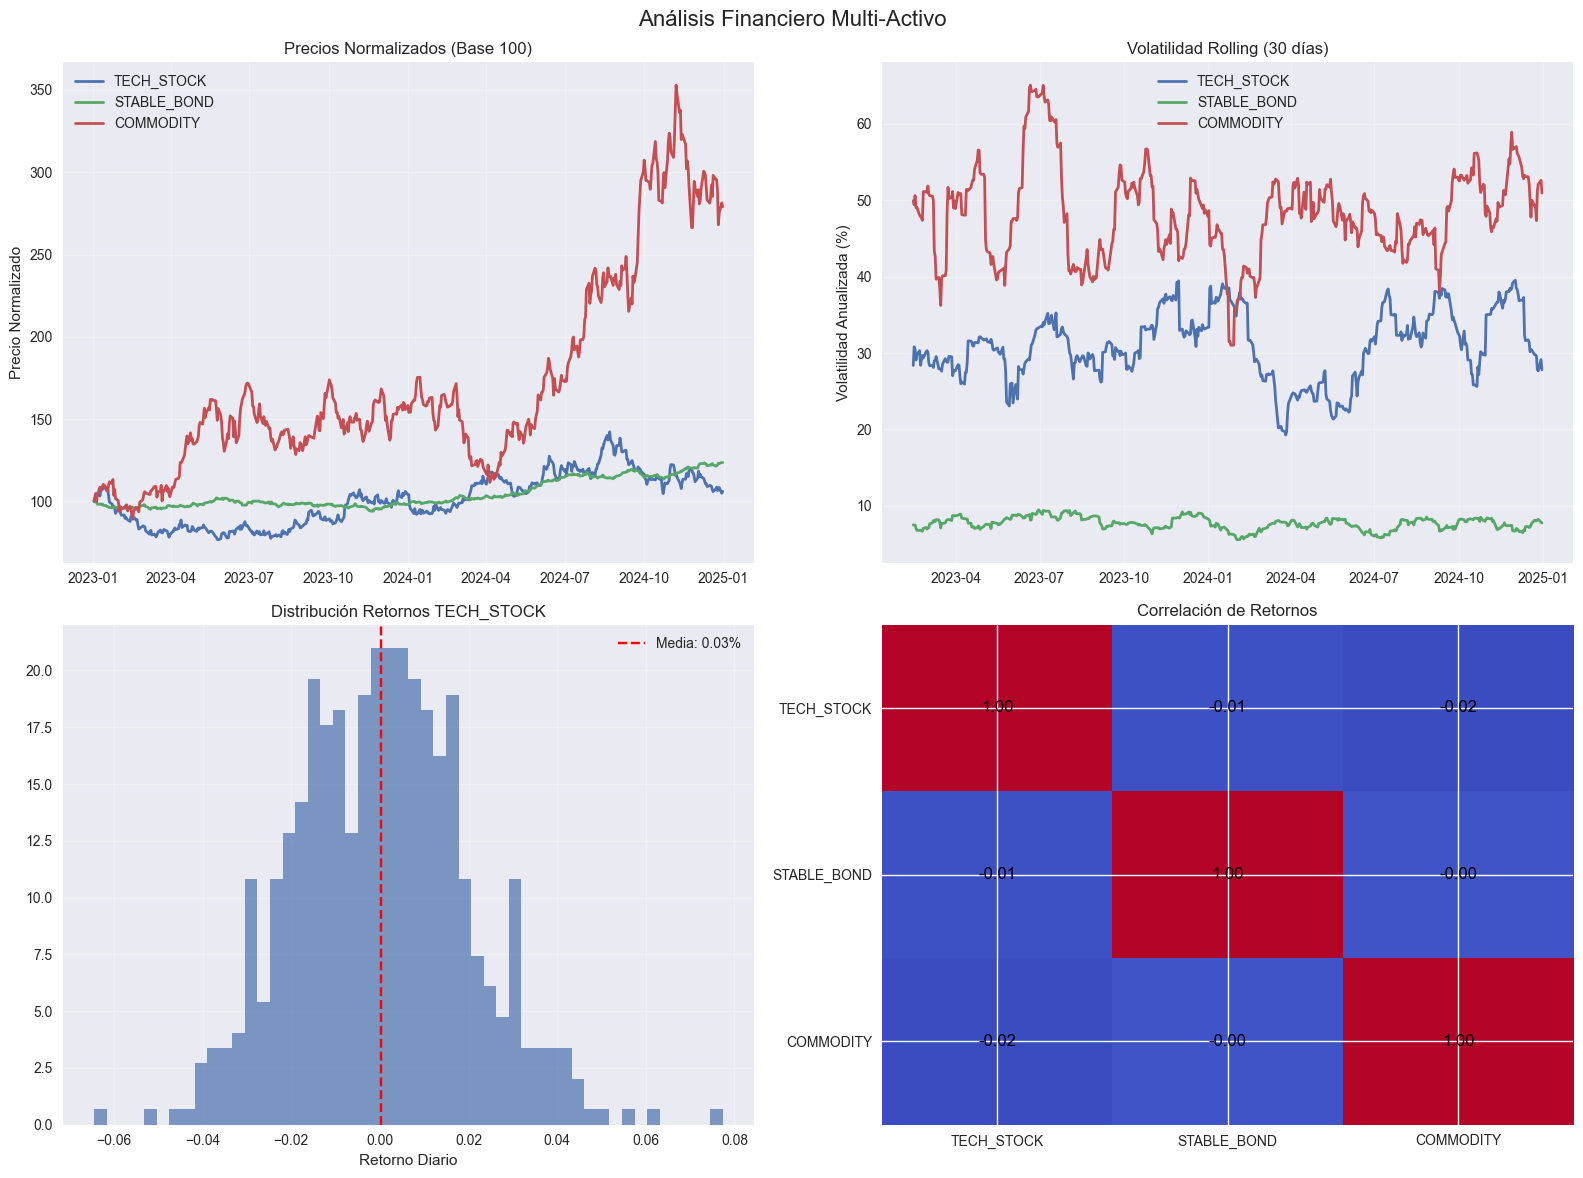

In [51]:

# CASO 3: Análisis financiero con múltiples activos
print("\nCASO 3: ANÁLISIS FINANCIERO")
print("-" * 30)

# Simular precios de múltiples activos
fechas_fin = pd.date_range('2023-01-01', '2024-12-31', freq='D')
fechas_fin = fechas_fin[fechas_fin.dayofweek < 5]  # Solo días hábiles

# Simular 3 activos con diferentes características
np.random.seed(42)
activos = {
    'TECH_STOCK': {
        'precio_inicial': 100,
        'volatilidad': 0.02,
        'tendencia': 0.0003
    },
    'STABLE_BOND': {
        'precio_inicial': 1000,
        'volatilidad': 0.005,
        'tendencia': 0.0001
    },
    'COMMODITY': {
        'precio_inicial': 50,
        'volatilidad': 0.03,
        'tendencia': 0.0002
    }
}

df_financiero = pd.DataFrame(index=fechas_fin)

for activo, params in activos.items():
    # Generar random walk con tendencia
    returns = np.random.normal(params['tendencia'], params['volatilidad'], len(fechas_fin))
    prices = [params['precio_inicial']]
    
    for ret in returns[1:]:
        prices.append(prices[-1] * (1 + ret))
    
    df_financiero[f'{activo}_precio'] = prices
    df_financiero[f'{activo}_retorno'] = df_financiero[f'{activo}_precio'].pct_change()

print("1. Resumen financiero:")
print(f"Período: {df_financiero.index.min()} a {df_financiero.index.max()}")
print(f"Días de trading: {len(df_financiero)}")

# Calcular métricas financieras
print("\n2. Métricas por activo:")
for activo in activos.keys():
    precio_col = f'{activo}_precio'
    retorno_col = f'{activo}_retorno'
    
    precio_inicial = df_financiero[precio_col].iloc[0]
    precio_final = df_financiero[precio_col].iloc[-1]
    retorno_total = (precio_final / precio_inicial - 1) * 100
    volatilidad_anual = df_financiero[retorno_col].std() * np.sqrt(252) * 100
    
    print(f"{activo}:")
    print(f"  Retorno total: {retorno_total:.1f}%")
    print(f"  Volatilidad anual: {volatilidad_anual:.1f}%")

# Matriz de correlaciones
print("\n3. Correlación de retornos:")
retornos_cols = [col for col in df_financiero.columns if 'retorno' in col]
correlacion_retornos = df_financiero[retornos_cols].corr()
print(correlacion_retornos)

# Visualización financiera
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Financiero Multi-Activo', fontsize=16)

# Precios normalizados
precios_norm = df_financiero[[col for col in df_financiero.columns if 'precio' in col]].copy()
for col in precios_norm.columns:
    precios_norm[col] = precios_norm[col] / precios_norm[col].iloc[0] * 100

for col in precios_norm.columns:
    axes[0, 0].plot(precios_norm.index, precios_norm[col], 
                   label=col.replace('_precio', ''), linewidth=2)
axes[0, 0].set_title('Precios Normalizados (Base 100)')
axes[0, 0].set_ylabel('Precio Normalizado')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Volatilidad rolling
vol_window = 30
for activo in activos.keys():
    retorno_col = f'{activo}_retorno'
    vol_rolling = df_financiero[retorno_col].rolling(vol_window).std() * np.sqrt(252) * 100
    axes[0, 1].plot(df_financiero.index, vol_rolling, 
                   label=activo, linewidth=2)
axes[0, 1].set_title(f'Volatilidad Rolling ({vol_window} días)')
axes[0, 1].set_ylabel('Volatilidad Anualizada (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribución de retornos
retorno_tech = df_financiero['TECH_STOCK_retorno'].dropna()
axes[1, 0].hist(retorno_tech, bins=50, alpha=0.7, density=True)
axes[1, 0].axvline(retorno_tech.mean(), color='red', linestyle='--', 
                  label=f'Media: {retorno_tech.mean()*100:.2f}%')
axes[1, 0].set_title('Distribución Retornos TECH_STOCK')
axes[1, 0].set_xlabel('Retorno Diario')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Heatmap correlaciones
im = axes[1, 1].imshow(correlacion_retornos.values, cmap='coolwarm', aspect='auto')
axes[1, 1].set_xticks(range(len(correlacion_retornos.columns)))
axes[1, 1].set_yticks(range(len(correlacion_retornos.columns)))
axes[1, 1].set_xticklabels([col.replace('_retorno', '') for col in correlacion_retornos.columns])
axes[1, 1].set_yticklabels([col.replace('_retorno', '') for col in correlacion_retornos.columns])
axes[1, 1].set_title('Correlación de Retornos')

# Agregar valores en el heatmap
for i in range(len(correlacion_retornos.columns)):
    for j in range(len(correlacion_retornos.columns)):
        axes[1, 1].text(j, i, f'{correlacion_retornos.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


In [52]:

print("\nTodos los casos prácticos completados.")
print("Estas técnicas pueden aplicarse a:")
print("- Análisis de KPIs de negocio")
print("- Monitoreo de sistemas y performance")
print("- Análisis de tendencias de mercado")
print("- Optimización de procesos temporales")
print("- Detección de patrones y anomalías")


Todos los casos prácticos completados.
Estas técnicas pueden aplicarse a:
- Análisis de KPIs de negocio
- Monitoreo de sistemas y performance
- Análisis de tendencias de mercado
- Optimización de procesos temporales
- Detección de patrones y anomalías


## 12. Resumen y Mejores Prácticas

Recapitulación de conceptos clave y recomendaciones para el trabajo profesional con series temporales en pandas.

In [ ]:
# Resumen y mejores prácticas para series temporales en pandas

print("RESUMEN: SERIES TEMPORALES CON PANDAS")
print("=" * 50)

# 1. Checklist de mejores prácticas
print("1. CHECKLIST DE MEJORES PRÁCTICAS:")
print("-" * 40)

mejores_practicas = {
    "Preparación de datos": [
        "✓ Siempre convertir columnas de fecha a datetime",
        "✓ Establecer fechas como índice cuando sea apropiado",
        "✓ Verificar y manejar datos faltantes",
        "✓ Asegurar frecuencia consistente",
        "✓ Manejar zonas horarias apropiadamente"
    ],
    
    "Análisis temporal": [
        "✓ Explorar tendencias con rolling statistics",
        "✓ Identificar patrones estacionales",
        "✓ Usar resampling para diferentes granularidades",
        "✓ Aplicar shift() para análisis de lag",
        "✓ Implementar agrupaciones temporales significativas"
    ],
    
    "Visualización": [
        "✓ Usar gráficos de línea para series temporales",
        "✓ Incluir bandas de confianza cuando sea relevante",
        "✓ Destacar eventos importantes",
        "✓ Usar subplots para múltiples series",
        "✓ Considerar heatmaps para patrones temporales"
    ],
    
    "Performance": [
        "✓ Usar DatetimeIndex para mejor rendimiento",
        "✓ Evitar loops explícitos, usar operaciones vectorizadas",
        "✓ Filtrar datos innecesarios antes de operaciones pesadas",
        "✓ Considerar chunking para datasets muy grandes",
        "✓ Usar .loc para filtrado temporal eficiente"
    ]
}

for categoria, practicas in mejores_practicas.items():
    print(f"\n{categoria.upper()}:")
    for practica in practicas:
        print(f"  {practica}")

# 2. Funciones utilitarias comunes
print("\n\n2. FUNCIONES UTILITARIAS COMUNES:")
print("-" * 40)

class SeriesTemporalesUtils:
    """Utilidades comunes para análisis de series temporales"""
    
    @staticmethod
    def validar_serie_temporal(df, col_fecha=None, col_valor=None):
        """Valida y prepara una serie temporal"""
        print("Validando serie temporal...")
        
        if col_fecha and col_fecha in df.columns:
            df[col_fecha] = pd.to_datetime(df[col_fecha])
            df.set_index(col_fecha, inplace=True)
        
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("El índice debe ser DatetimeIndex")
        
        # Verificar duplicados
        duplicados = df.index.duplicated().sum()
        if duplicados > 0:
            print(f"⚠️  Encontrados {duplicados} timestamps duplicados")
        
        # Verificar gaps
        if hasattr(df.index, 'freq') and df.index.freq:
            expected_length = (df.index.max() - df.index.min()) / df.index.freq + 1
            actual_length = len(df)
            if actual_length < expected_length:
                print(f"⚠️  Posibles gaps en los datos: {expected_length - actual_length} registros faltantes")
        
        # Estadísticas básicas
        print(f"✓ Período: {df.index.min()} a {df.index.max()}")
        print(f"✓ Registros: {len(df)}")
        if col_valor and col_valor in df.columns:
            print(f"✓ Valores faltantes: {df[col_valor].isna().sum()}")
        
        return df
    
    @staticmethod
    def detectar_outliers_temporales(serie, metodo='iqr', ventana=30):
        """Detecta outliers considerando contexto temporal"""
        
        if metodo == 'iqr':
            # IQR rolling
            Q1 = serie.rolling(window=ventana, center=True).quantile(0.25)
            Q3 = serie.rolling(window=ventana, center=True).quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR
            
        elif metodo == 'zscore':
            # Z-score rolling
            media_rolling = serie.rolling(window=ventana, center=True).mean()
            std_rolling = serie.rolling(window=ventana, center=True).std()
            zscore = (serie - media_rolling) / std_rolling
            outliers = (zscore.abs() > 3)
            return outliers
        
        outliers = (serie < limite_inferior) | (serie > limite_superior)
        return outliers
    
    @staticmethod
    def resumen_temporal(df, col_valor):
        """Genera resumen completo de una serie temporal"""
        
        print(f"RESUMEN TEMPORAL - {col_valor}")
        print("-" * 30)
        
        # Estadísticas básicas
        print("Estadísticas básicas:")
        print(f"  Media: {df[col_valor].mean():.2f}")
        print(f"  Mediana: {df[col_valor].median():.2f}")
        print(f"  Desviación estándar: {df[col_valor].std():.2f}")
        print(f"  Mínimo: {df[col_valor].min():.2f}")
        print(f"  Máximo: {df[col_valor].max():.2f}")
        
        # Tendencia
        if len(df) > 1:
            tendencia = (df[col_valor].iloc[-1] - df[col_valor].iloc[0]) / len(df)
            print(f"  Tendencia promedio: {tendencia:.4f} por período")
        
        # Datos faltantes
        faltantes = df[col_valor].isna().sum()
        porcentaje_faltantes = (faltantes / len(df)) * 100
        print(f"  Datos faltantes: {faltantes} ({porcentaje_faltantes:.1f}%)")
        
        # Patrones estacionales básicos
        if hasattr(df.index, 'month'):
            variacion_mensual = df.groupby(df.index.month)[col_valor].mean().std()
            print(f"  Variación estacional (monthly): {variacion_mensual:.2f}")
        
        return {
            'media': df[col_valor].mean(),
            'std': df[col_valor].std(),
            'faltantes': faltantes,
            'tendencia': tendencia if len(df) > 1 else 0
        }

# Demostrar uso de utilidades
print("\n3. EJEMPLO DE USO DE UTILIDADES:")
print("-" * 40)

# Crear datos de ejemplo
fechas_demo = pd.date_range('2024-01-01', periods=100, freq='D')
valores_demo = np.cumsum(np.random.randn(100)) + 100
df_demo = pd.DataFrame({
    'fecha': fechas_demo,
    'valor': valores_demo
})

# Aplicar validación
utils = SeriesTemporalesUtils()
df_validado = utils.validar_serie_temporal(df_demo.copy(), 'fecha', 'valor')

# Generar resumen
resumen = utils.resumen_temporal(df_validado, 'valor')

# Detectar outliers
outliers = utils.detectar_outliers_temporales(df_validado['valor'])
print(f"\nOutliers detectados: {outliers.sum()}")

# 4. Errores comunes y cómo evitarlos
print("\n\n4. ERRORES COMUNES Y SOLUCIONES:")
print("-" * 40)

errores_comunes = {
    "❌ Índice no es DatetimeIndex": {
        "Problema": "Usar strings como fechas en lugar de datetime",
        "Solución": "df.index = pd.to_datetime(df.index)"
    },
    
    "❌ Mezclar zonas horarias": {
        "Problema": "Combinar datos de diferentes timezones sin conversión",
        "Solución": "Usar .tz_localize() y .tz_convert() apropiadamente"
    },
    
    "❌ Frecuencia inconsistente": {
        "Problema": "Datos con gaps o frecuencia irregular",
        "Solución": "Usar .resample() o .asfreq() para normalizar"
    },
    
    "❌ Ignorar datos faltantes": {
        "Problema": "No tratar NaN en series temporales",
        "Solución": "Usar .interpolate() o .fillna() apropiadamente"
    },
    
    "❌ Análisis sin contexto temporal": {
        "Problema": "Aplicar técnicas de datos estáticos a series temporales",
        "Solución": "Usar rolling windows y considerar autocorrelación"
    }
}

for error, info in errores_comunes.items():
    print(f"\n{error}")
    print(f"  Problema: {info['Problema']}")
    print(f"  Solución: {info['Solución']}")

# 5. Recursos adicionales
print("\n\n5. RECURSOS PARA PROFUNDIZAR:")
print("-" * 40)

recursos = [
    "📚 Documentación pandas: https://pandas.pydata.org/docs/user_guide/timeseries.html",
    "📈 Análisis de series temporales: statsmodels, prophet, sktime",
    "🎯 Visualización avanzada: plotly para gráficos interactivos",
    "⚡ Performance: usar numba para operaciones personalizadas rápidas",
    "🔧 Datos grandes: dask para processing distribuido",
    "📊 Machine learning temporal: feature engineering específico para tiempo"
]

for recurso in recursos:
    print(f"  {recurso}")

# Resumen final
print("\n\n" + "="*50)
print("CONCEPTOS CLAVE CUBIERTOS:")
print("="*50)

conceptos = [
    "1. Creación y manipulación de DatetimeIndex",
    "2. Resampling y agregaciones temporales", 
    "3. Rolling windows y estadísticas móviles",
    "4. Operaciones de shift y lag",
    "5. Filtrado y selección temporal",
    "6. Detección de tendencias y estacionalidad",
    "7. Agrupaciones temporales complejas",
    "8. Visualización especializada",
    "9. Manejo de zonas horarias",
    "10. Tratamiento de datos faltantes temporales",
    "11. Casos prácticos reales",
    "12. Mejores prácticas y optimización"
]

for concepto in conceptos:
    print(f"✓ {concepto}")

print("\n🎉 ¡Felicitaciones! Has completado el curso de Series Temporales con Pandas.")
print("Ahora tienes las herramientas para analizar cualquier dataset temporal de manera profesional.")

RESUMEN: SERIES TEMPORALES CON PANDAS
1. CHECKLIST DE MEJORES PRÁCTICAS:
----------------------------------------

PREPARACIÓN DE DATOS:
  ✓ Siempre convertir columnas de fecha a datetime
  ✓ Establecer fechas como índice cuando sea apropiado
  ✓ Verificar y manejar datos faltantes
  ✓ Asegurar frecuencia consistente
  ✓ Manejar zonas horarias apropiadamente

ANÁLISIS TEMPORAL:
  ✓ Explorar tendencias con rolling statistics
  ✓ Identificar patrones estacionales
  ✓ Usar resampling para diferentes granularidades
  ✓ Aplicar shift() para análisis de lag
  ✓ Implementar agrupaciones temporales significativas

VISUALIZACIÓN:
  ✓ Usar gráficos de línea para series temporales
  ✓ Incluir bandas de confianza cuando sea relevante
  ✓ Destacar eventos importantes
  ✓ Usar subplots para múltiples series
  ✓ Considerar heatmaps para patrones temporales

PERFORMANCE:
  ✓ Usar DatetimeIndex para mejor rendimiento
  ✓ Evitar loops explícitos, usar operaciones vectorizadas
  ✓ Filtrar datos innecesar